# 01. EDA train.csv и baseline прогноза гостей

## 1. Введение

Цель проекта - построить почасовой прогноз числа гостей ресторана "Вкусно - и точка" на неделю
`27.04.2026-03.05.2026`. В этом ноутбуке фокус только на ML-части: понять временной ряд,
построить честный baseline и подготовить основу для прогнозной модели.

Нельзя сразу обучать модель "на вскидку": временной ряд почти всегда содержит сезонности, смены режима,
неполные дни, выбросы и лаговые зависимости. Если не проверить эти свойства, можно получить модель,
которая хорошо выглядит на случайном разбиении, но плохо прогнозирует будущую неделю.

В этом ноутбуке train.csv рассматривается как основной источник ML-части. Мы проверим качество данных,
сезонности, лаги, выбросы, выберем временное разбиение, построим baseline-модели и обучим первую
LightGBM-модель только на признаках из train.csv.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 110,
        "savefig.dpi": 160,
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "axes.titleweight": "bold",
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "font.size": 10,
    }
)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "train.csv"
FIG_DIR = ROOT / "artifacts" / "figures"
REPORT_DIR = ROOT / "artifacts" / "reports"
for path in (FIG_DIR, REPORT_DIR):
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DOW_RU = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]


def savefig(name: str) -> None:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"saved: {path.relative_to(ROOT)}")


def format_date_axis(ax, locator: str = "year") -> None:
    if locator == "month":
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    else:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)


def note(text: str) -> None:
    display(Markdown(text.strip()))


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def wape(y_true, y_pred) -> float:
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return float(np.abs(y_true - y_pred).sum() / denom * 100)


def smape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom > 0
    if not mask.any():
        return np.nan
    return float(np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100)


def regression_metrics(y_true, y_pred) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred),
    }

## 2. Загрузка данных

Загружаем `train.csv`, приводим типы и сразу фиксируем базовые границы ряда: период, часы работы,
количество дат и статистику `guests_count`.

In [2]:
raw = pd.read_csv(DATA_PATH)

display(raw.head())
display(raw.tail())
print(f"shape: {raw.shape}")
display(raw.describe(include="all"))
raw.info()

df = raw.copy()
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
df["sale_hour"] = pd.to_numeric(df["sale_hour"], errors="coerce").astype("Int64")
df["guests_count"] = pd.to_numeric(df["guests_count"], errors="coerce")
df = df.sort_values(["sale_date", "sale_hour"]).reset_index(drop=True)

observed_hours = sorted(df["sale_hour"].dropna().astype(int).unique())
basic_stats = pd.DataFrame(
    {
        "metric": [
            "date_min",
            "date_max",
            "unique_dates",
            "hour_min",
            "hour_max",
            "rows",
            "guests_mean",
            "guests_median",
            "guests_min",
            "guests_max",
        ],
        "value": [
            df["sale_date"].min().date(),
            df["sale_date"].max().date(),
            df["sale_date"].nunique(),
            min(observed_hours),
            max(observed_hours),
            len(df),
            round(df["guests_count"].mean(), 2),
            round(df["guests_count"].median(), 2),
            round(df["guests_count"].min(), 2),
            round(df["guests_count"].max(), 2),
        ],
    }
)
display(basic_stats)

display(Markdown(
    f"""
    **Вывод по загрузке.** В данных {len(df):,} строк за период
    `{df['sale_date'].min().date()} - {df['sale_date'].max().date()}`.
    Фактические значения `sale_hour`: `{min(observed_hours)}..{max(observed_hours)}`.
    Это согласуется с рабочим днем `7:00-23:00`: `sale_hour=22` означает интервал
    `22:00-23:00`. Для ML-прогноза нужен старт часа `7..22`; отдельного таргета
    `sale_hour=23` в истории нет.
    """
))

,sale_date,sale_hour,guests_count
0,2019-01-02,7,5
1,2019-01-02,8,11
2,2019-01-02,9,14
3,2019-01-02,10,17
4,2019-01-02,11,28


,sale_date,sale_hour,guests_count
40538,2026-04-26,18,127
40539,2026-04-26,19,128
40540,2026-04-26,20,100
40541,2026-04-26,21,70
40542,2026-04-26,22,76


shape: (40543, 3)


,sale_date,sale_hour,guests_count
count,40543,40543.000000,40543.000000
unique,2543,NaN,NaN
top,2019-01-02,NaN,NaN
freq,16,NaN,NaN
mean,NaN,14.502947,103.789729
std,NaN,4.606218,45.204182
min,NaN,7.000000,1.000000
25%,NaN,11.000000,70.000000
50%,NaN,15.000000,101.000000
75%,NaN,18.000000,135.000000


<class 'pandas.DataFrame'>
RangeIndex: 40543 entries, 0 to 40542
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   sale_date     40543 non-null  str  
 1   sale_hour     40543 non-null  int64
 2   guests_count  40543 non-null  int64
dtypes: int64(2), str(1)
memory usage: 950.4 KB


,metric,value
0,date_min,2019-01-02
1,date_max,2026-04-26
2,unique_dates,2543
3,hour_min,7
4,hour_max,22
5,rows,40543
6,guests_mean,103.79
7,guests_median,101.0
8,guests_min,1
9,guests_max,299



    **Вывод по загрузке.** В данных 40,543 строк за период
    `2019-01-02 - 2026-04-26`.
    Фактические значения `sale_hour`: `7..22`.
    Это согласуется с рабочим днем `7:00-23:00`: `sale_hour=22` означает интервал
    `22:00-23:00`. Для ML-прогноза нужен старт часа `7..22`; отдельного таргета
    `sale_hour=23` в истории нет.
    

## 3. Проверка качества данных

Проверяем пропуски, дубли по ключу `sale_date + sale_hour`, отрицательные и нулевые значения,
часы вне рабочего окна, неполные дни, разрывы временной сетки и аномально большие значения.

,Проверка,Значение
0,Пропуски во всех колонках,0.0
1,Дубли sale_date + sale_hour,0.0
2,Отрицательный guests_count,0.0
3,Нулевой guests_count,0.0
4,Пропущенные слоты дата-час,2209.0
5,Неполные дни,30.0
6,IQR-выбросы по часам,231.0
7,Верхний IQR-порог guests_count,232.5


saved: artifacts\figures\01_missing_values.png


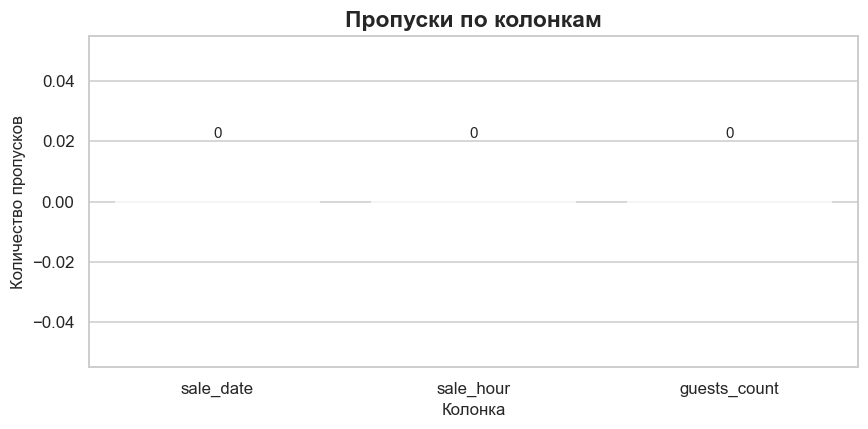

**Вывод.** Этот график быстро проверяет, можно ли обучать модель без дополнительной импутации.
Если пропуски появились бы в `sale_date`, `sale_hour` или `guests_count`, их нужно было бы обработать до любых лагов.

saved: artifacts\figures\02_hours_per_day.png


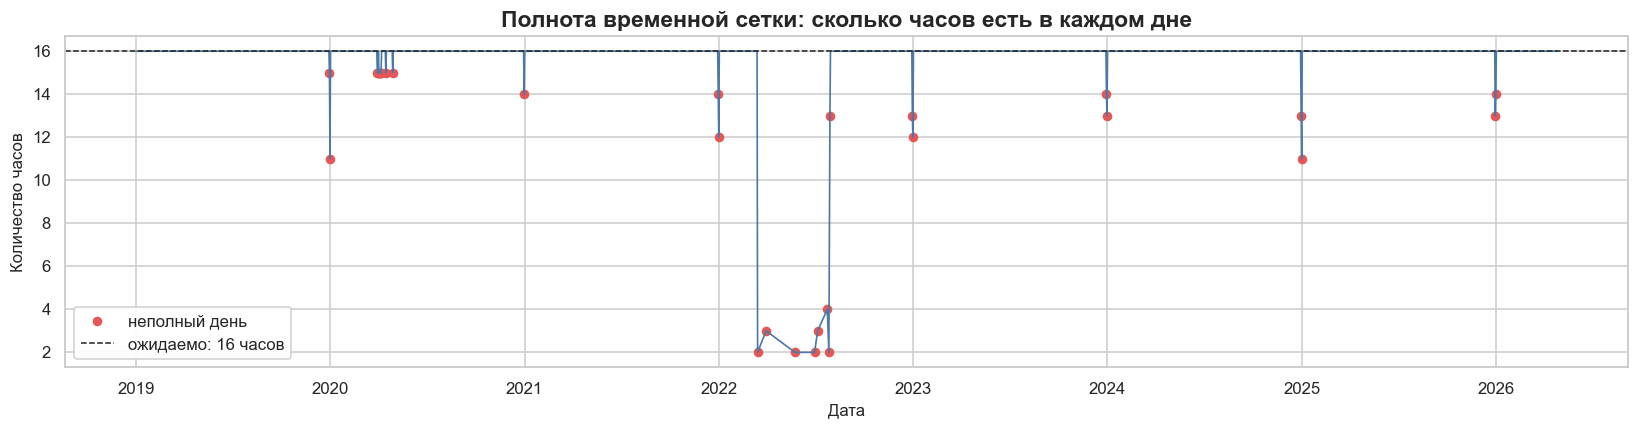

**Вывод.** В фактическом окне `7:00-23:00` неполных дней: `30`.
Неполные дни важны для ML, потому что rolling- и lag-признаки могут получить искусственные провалы.

saved: artifacts\figures\03_guests_distribution_and_boxplot.png


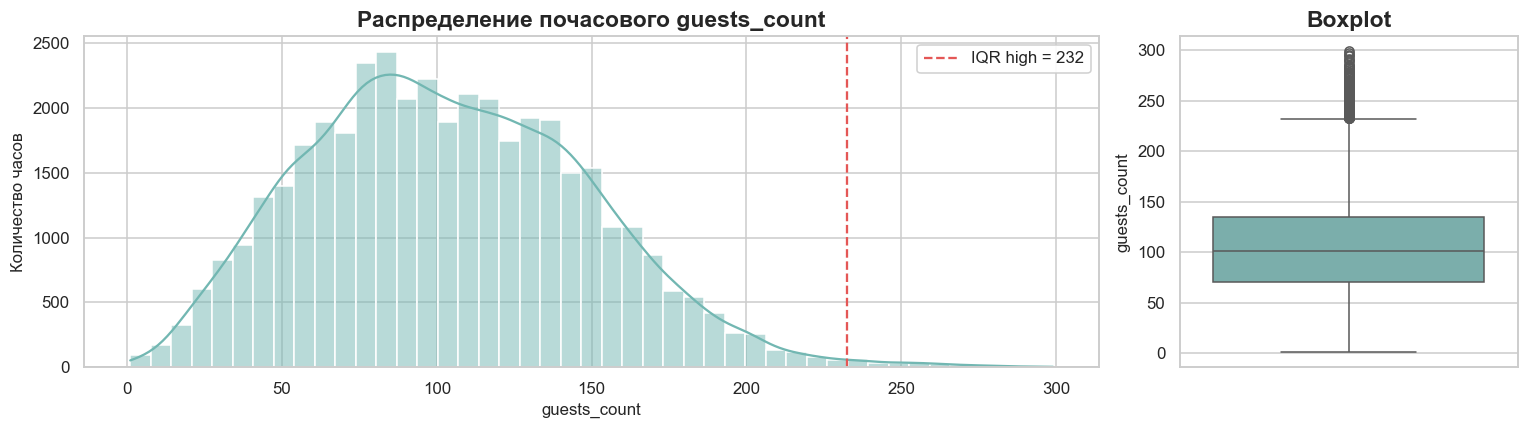

**Вывод.** Распределение асимметрично: пики спроса выше типичного уровня встречаются, но максимум `299`
похож на бизнес-пик, а не на очевидную ошибку. Такие точки лучше не удалять автоматически: модель должна понимать пиковые часы.

,sale_date,hours_count
363,2019-12-31,15
364,2020-01-01,11
453,2020-03-30,15
454,2020-03-31,15
456,2020-04-02,15
457,2020-04-03,15
458,2020-04-04,15
459,2020-04-05,15
460,2020-04-06,15
469,2020-04-15,15


In [3]:
min_hour, max_hour = min(observed_hours), max(observed_hours)
expected_hours = list(range(min_hour, max_hour + 1))
full_grid = pd.MultiIndex.from_product(
    [pd.date_range(df["sale_date"].min(), df["sale_date"].max(), freq="D"), expected_hours],
    names=["sale_date", "sale_hour"],
).to_frame(index=False)
grid_check = full_grid.merge(df, on=["sale_date", "sale_hour"], how="left", indicator=True)
missing_grid = grid_check[grid_check["_merge"] == "left_only"]

hours_per_day = df.groupby("sale_date")["sale_hour"].nunique().rename("hours_count").reset_index()
incomplete_days = hours_per_day[hours_per_day["hours_count"] < len(expected_hours)]

q1, q3 = df["guests_count"].quantile([0.25, 0.75])
iqr = q3 - q1
high_threshold = q3 + 1.5 * iqr
low_threshold = max(0, q1 - 1.5 * iqr)
outlier_rows = df[(df["guests_count"] > high_threshold) | (df["guests_count"] < low_threshold)]

quality_report = pd.DataFrame(
    {
        "Проверка": [
            "Пропуски во всех колонках",
            "Дубли sale_date + sale_hour",
            "Отрицательный guests_count",
            "Нулевой guests_count",
            "Пропущенные слоты дата-час",
            "Неполные дни",
            "IQR-выбросы по часам",
            "Верхний IQR-порог guests_count",
        ],
        "Значение": [
            int(df.isna().sum().sum()),
            int(df.duplicated(["sale_date", "sale_hour"]).sum()),
            int((df["guests_count"] < 0).sum()),
            int((df["guests_count"] == 0).sum()),
            int(len(missing_grid)),
            int(len(incomplete_days)),
            int(len(outlier_rows)),
            round(float(high_threshold), 2),
        ],
    }
)
display(quality_report)

fig, ax = plt.subplots(figsize=(8, 4))
missing = df.isna().sum().sort_values(ascending=False)
bars = sns.barplot(x=missing.index, y=missing.values, ax=ax, color="#4C78A8")
ax.set_title("Пропуски по колонкам")
ax.set_xlabel("Колонка")
ax.set_ylabel("Количество пропусков")
for bar, value in zip(bars.patches, missing.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, str(int(value)), ha="center", va="bottom")
savefig("01_missing_values.png")
plt.show()
note("""
**Вывод.** Этот график быстро проверяет, можно ли обучать модель без дополнительной импутации.
Если пропуски появились бы в `sale_date`, `sale_hour` или `guests_count`, их нужно было бы обработать до любых лагов.
""")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(hours_per_day["sale_date"], hours_per_day["hours_count"], linewidth=1.1, color="#4C78A8")
if not incomplete_days.empty:
    ax.scatter(incomplete_days["sale_date"], incomplete_days["hours_count"], color="#E45756", s=28, label="неполный день")
ax.axhline(len(expected_hours), color="#222222", linestyle="--", linewidth=1, label=f"ожидаемо: {len(expected_hours)} часов")
ax.set_title("Полнота временной сетки: сколько часов есть в каждом дне")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество часов")
format_date_axis(ax)
ax.legend(loc="lower left")
savefig("02_hours_per_day.png")
plt.show()
note(f"""
**Вывод.** В фактическом окне `{min_hour}:00-{max_hour + 1}:00` неполных дней: `{len(incomplete_days)}`.
Неполные дни важны для ML, потому что rolling- и lag-признаки могут получить искусственные провалы.
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [3, 1]})
sns.histplot(df["guests_count"], bins=45, kde=True, ax=axes[0], color="#72B7B2")
axes[0].axvline(high_threshold, color="#E45756", linestyle="--", label=f"IQR high = {high_threshold:.0f}")
axes[0].set_title("Распределение почасового guests_count")
axes[0].set_xlabel("guests_count")
axes[0].set_ylabel("Количество часов")
axes[0].legend()
sns.boxplot(data=df, y="guests_count", ax=axes[1], color="#72B7B2")
axes[1].set_title("Boxplot")
axes[1].set_ylabel("guests_count")
savefig("03_guests_distribution_and_boxplot.png")
plt.show()
note(f"""
**Вывод.** Распределение асимметрично: пики спроса выше типичного уровня встречаются, но максимум `{df['guests_count'].max():.0f}`
похож на бизнес-пик, а не на очевидную ошибку. Такие точки лучше не удалять автоматически: модель должна понимать пиковые часы.
""")

if not incomplete_days.empty:
    display(incomplete_days.head(15))
else:
    note("**Вывод.** Неполных дней относительно фактического окна часов не найдено.")

## 4. Базовая структура временного ряда

Создаем `timestamp = sale_date + sale_hour` и смотрим ряд во времени, сглаживания,
недельную и месячную агрегации.

saved: artifacts\figures\04_daily_trend_rolling.png


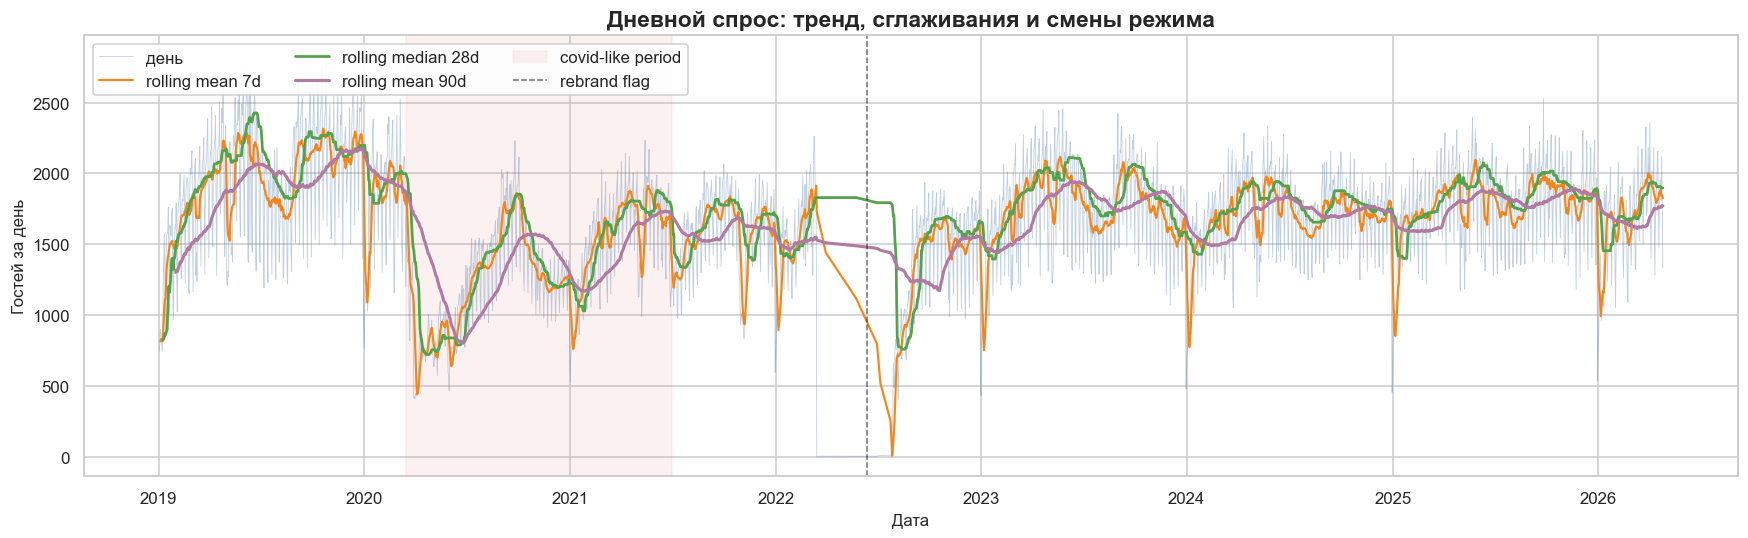

**Вывод.** Rolling-линии отделяют устойчивый уровень спроса от шумных дневных колебаний.
Для модели это аргумент в пользу `days_from_start`, флагов нестабильных периодов и rolling-признаков.

saved: artifacts\figures\05_weekly_monthly_trends.png


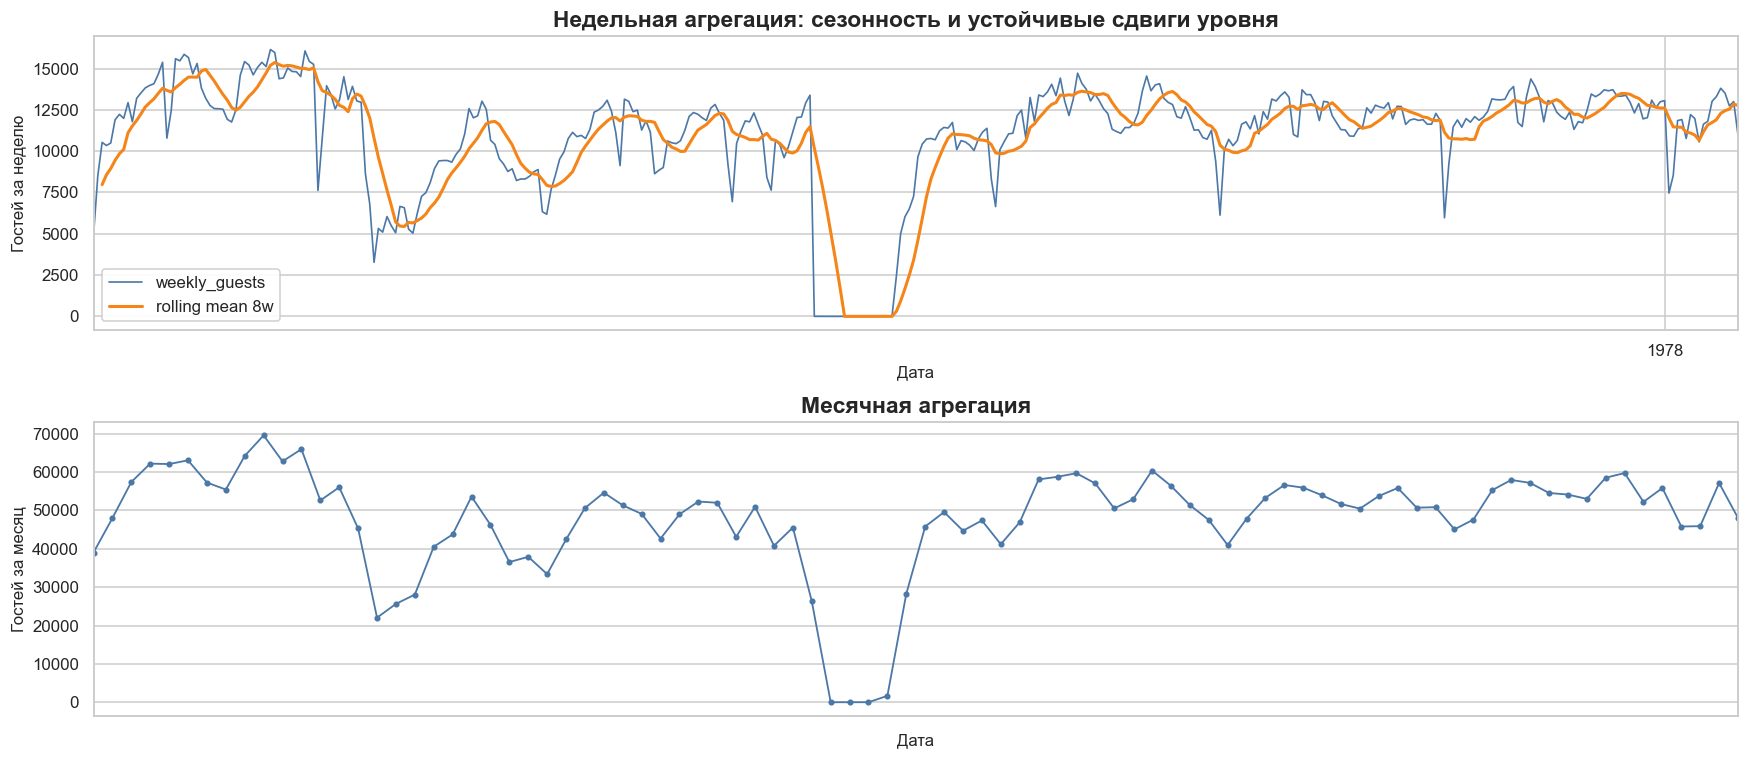

**Вывод.** Агрегации показывают, насколько меняется базовый уровень ряда по месяцам и годам.
Если уровень спроса плывет, модель только с `day_of_week + hour` будет систематически ошибаться на новых периодах.

In [4]:
df["timestamp"] = df["sale_date"] + pd.to_timedelta(df["sale_hour"].astype(int), unit="h")
df["date"] = df["sale_date"].dt.date
daily = df.groupby("sale_date", as_index=False).agg(
    guests_sum=("guests_count", "sum"),
    guests_mean=("guests_count", "mean"),
    hours=("sale_hour", "nunique"),
)
daily["rolling_7d_mean"] = daily["guests_sum"].rolling(7, min_periods=3).mean()
daily["rolling_28d_median"] = daily["guests_sum"].rolling(28, min_periods=7).median()
daily["rolling_90d_mean"] = daily["guests_sum"].rolling(90, min_periods=30).mean()
weekly = daily.set_index("sale_date")["guests_sum"].resample("W-MON").sum().rename("weekly_guests")
monthly = daily.set_index("sale_date")["guests_sum"].resample("MS").sum().rename("monthly_guests")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily["sale_date"], daily["guests_sum"], linewidth=0.55, alpha=0.35, color="#4C78A8", label="день")
ax.plot(daily["sale_date"], daily["rolling_7d_mean"], linewidth=1.4, color="#F58518", label="rolling mean 7d")
ax.plot(daily["sale_date"], daily["rolling_28d_median"], linewidth=1.8, color="#54A24B", label="rolling median 28d")
ax.plot(daily["sale_date"], daily["rolling_90d_mean"], linewidth=2.0, color="#B279A2", label="rolling mean 90d")
ax.axvspan(pd.Timestamp("2020-03-15"), pd.Timestamp("2021-06-30"), color="#E45756", alpha=0.08, label="covid-like period")
ax.axvline(pd.Timestamp("2022-06-12"), color="#222222", linestyle="--", linewidth=1, alpha=0.65, label="rebrand flag")
ax.set_title("Дневной спрос: тренд, сглаживания и смены режима")
ax.set_xlabel("Дата")
ax.set_ylabel("Гостей за день")
format_date_axis(ax)
ax.legend(ncol=3, loc="upper left")
savefig("04_daily_trend_rolling.png")
plt.show()
note("""
**Вывод.** Rolling-линии отделяют устойчивый уровень спроса от шумных дневных колебаний.
Для модели это аргумент в пользу `days_from_start`, флагов нестабильных периодов и rolling-признаков.
""")

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)
weekly.plot(ax=axes[0], color="#4C78A8", linewidth=1.1)
weekly.rolling(8, min_periods=3).mean().plot(ax=axes[0], color="#F58518", linewidth=2, label="rolling mean 8w")
axes[0].set_title("Недельная агрегация: сезонность и устойчивые сдвиги уровня")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Гостей за неделю")
format_date_axis(axes[0])
axes[0].legend()
monthly.plot(ax=axes[1], color="#4C78A8", marker="o", markersize=3, linewidth=1.2)
axes[1].set_title("Месячная агрегация")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Гостей за месяц")
format_date_axis(axes[1])
savefig("05_weekly_monthly_trends.png")
plt.show()
note("""
**Вывод.** Агрегации показывают, насколько меняется базовый уровень ряда по месяцам и годам.
Если уровень спроса плывет, модель только с `day_of_week + hour` будет систематически ошибаться на новых периодах.
""")

## 5. Сезонность и зависимости

Проверяем зависимости от часа, дня недели, месяца, типа дня, утреннего меню и основного меню.

saved: artifacts\figures\06_hourly_seasonality.png


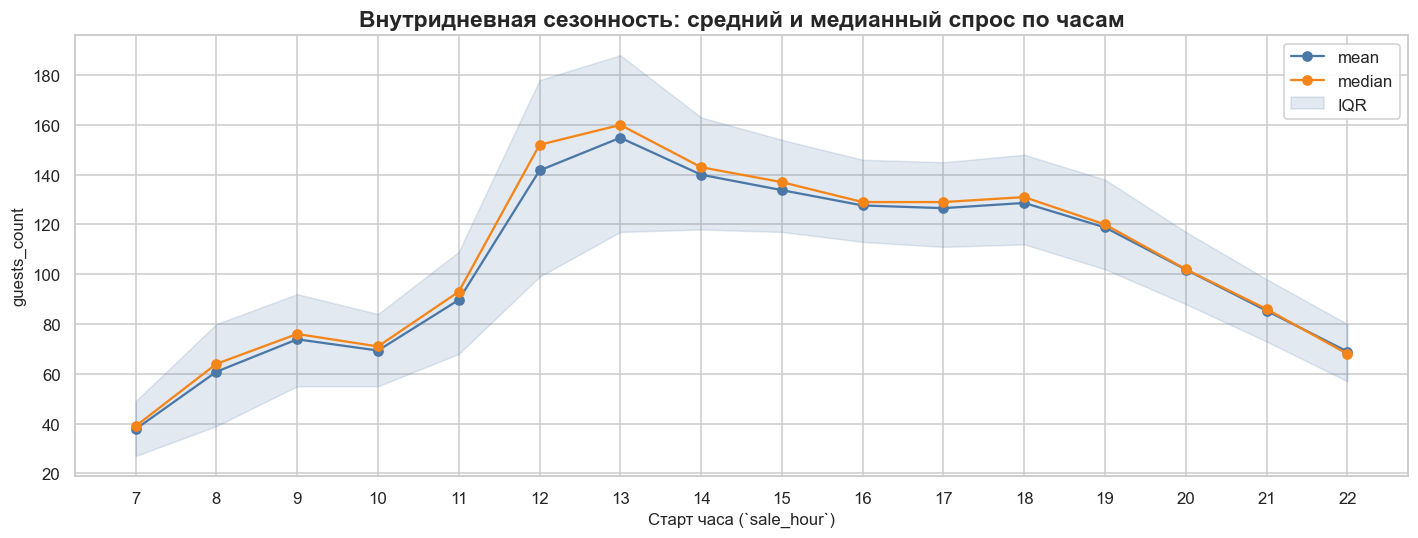

**Вывод.** Самый загруженный час по среднему значению: `13`.
Самый слабый час: `7`. Час дня - обязательный признак модели.

saved: artifacts\figures\07_hour_boxplot_and_weekday_bar.png


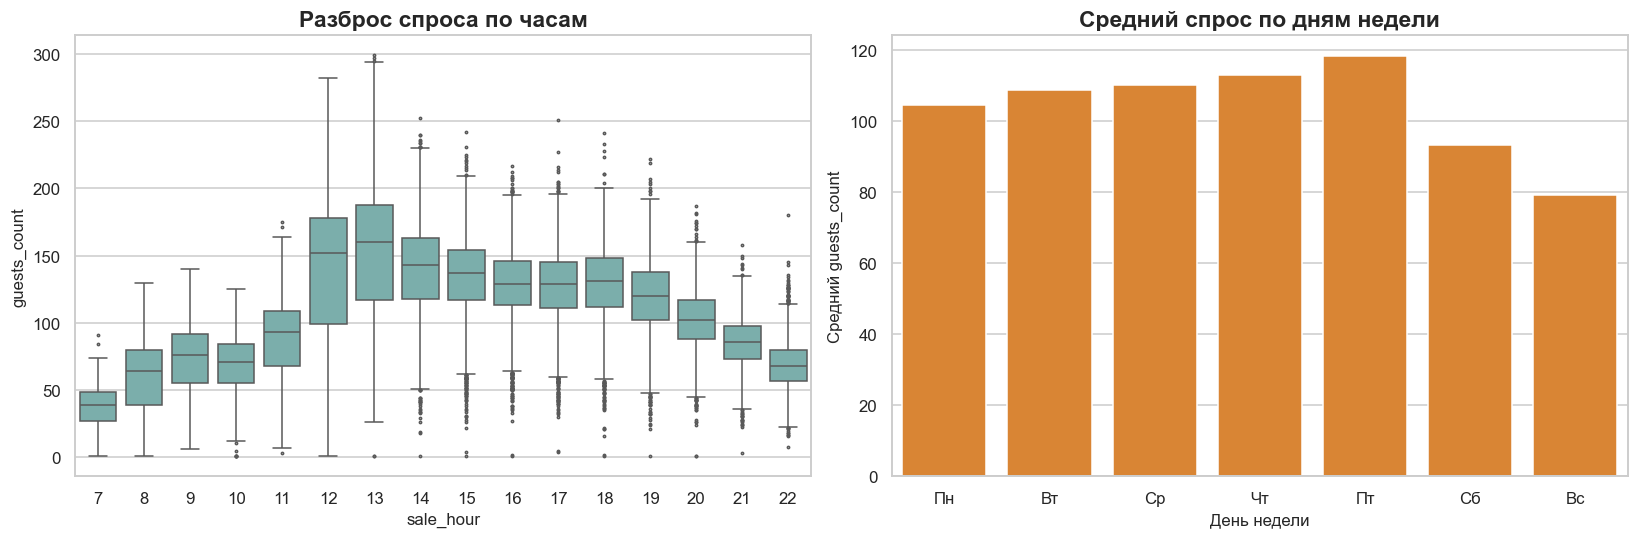

**Вывод.** Boxplot показывает, в какие часы ошибка прогноза потенциально дороже из-за большого разброса.
Дни недели заметно различаются, поэтому random split был бы некорректен и сгладил бы недельный паттерн.

saved: artifacts\figures\08_heatmap_dow_hour.png


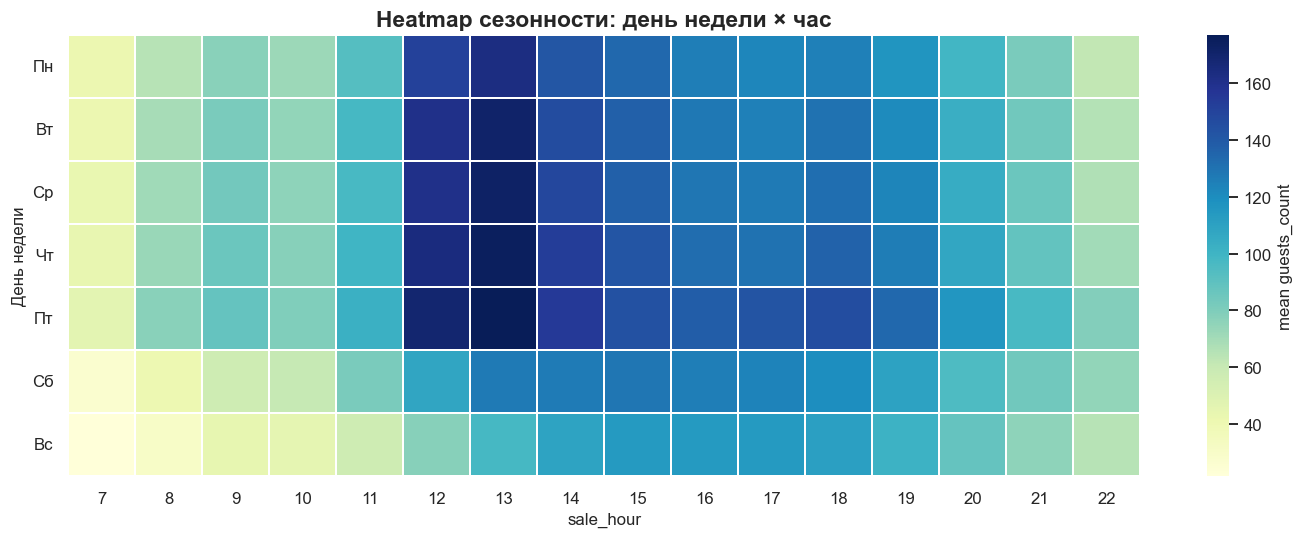

**Вывод.** Эта heatmap отвечает на главный вопрос сезонности: спрос зависит не только от часа и не только от дня,
а от их комбинации. Поэтому baseline `day_of_week + sale_hour` является сильной точкой отсчета.

saved: artifacts\figures\09_heatmap_recent_date_hour.png


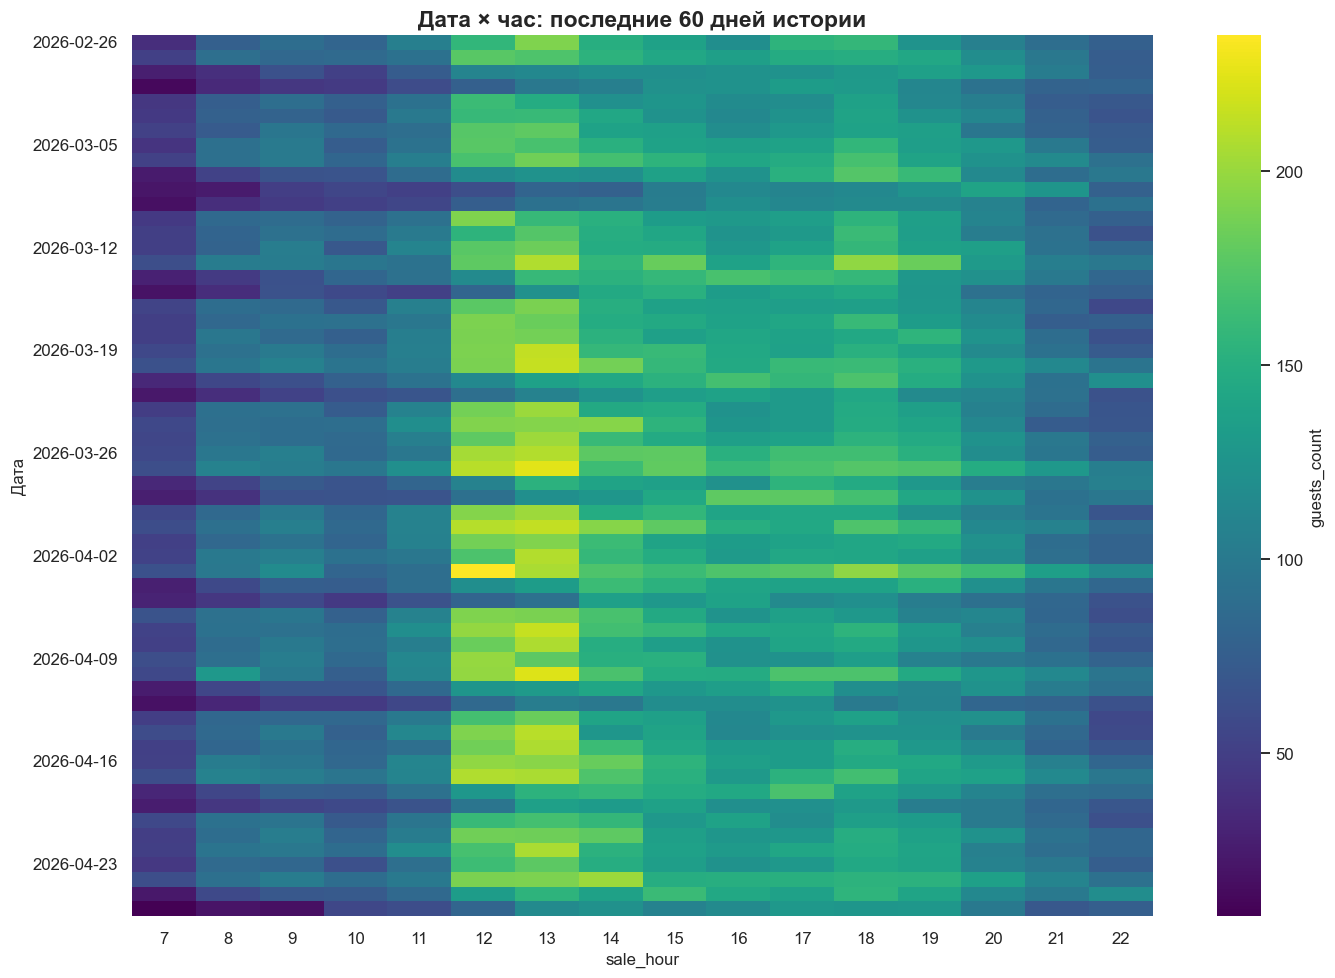

**Вывод.** Heatmap последних дней помогает увидеть локальные пики/провалы перед прогнозным периодом.
Это полезно для выбора recent-baseline и для диагностики, не меняется ли режим спроса прямо перед holdout.

saved: artifacts\figures\10_weekend_and_menu_effects.png


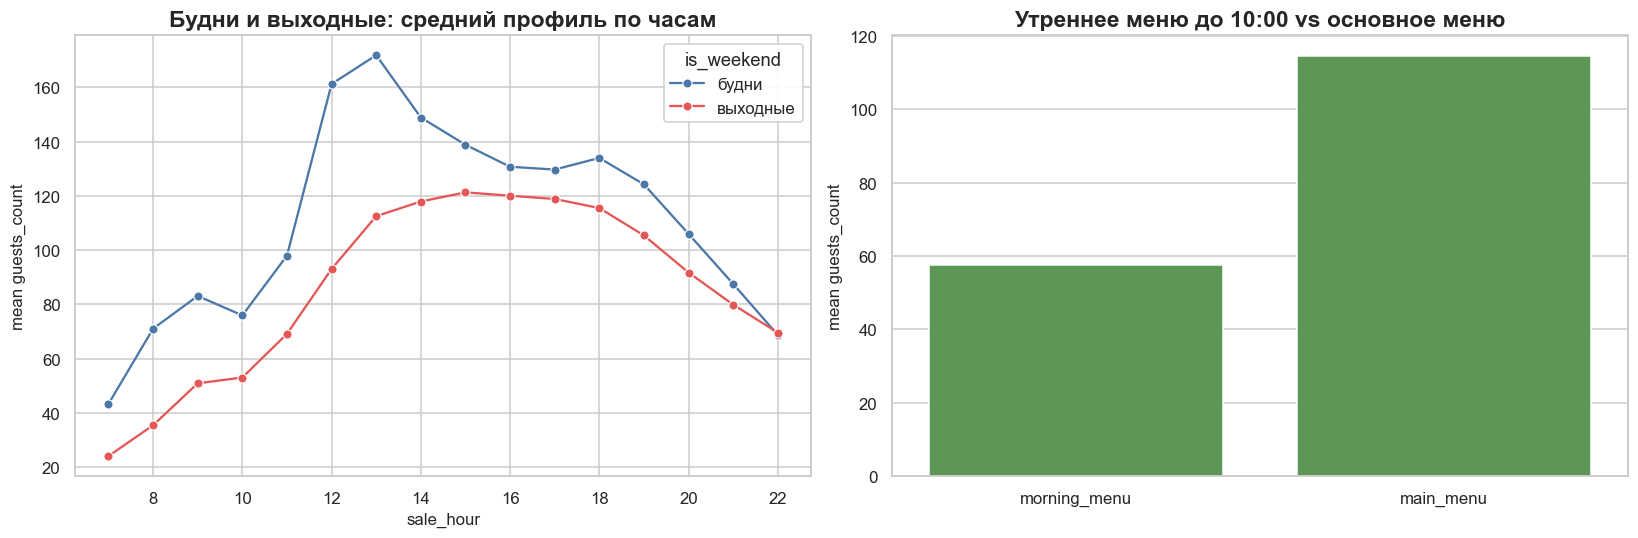

,mean,median,count
menu_period,,,
morning_menu,57.518670,54.0,7579
main_menu,114.428255,113.0,32964


**Вывод.** Различие утренних и основных часов подтверждает признак `is_morning_menu`.
Различие будней и выходных подтверждает `is_weekend` и отдельные паттерны по `day_of_week`.

saved: artifacts\figures\11_heatmap_year_month.png


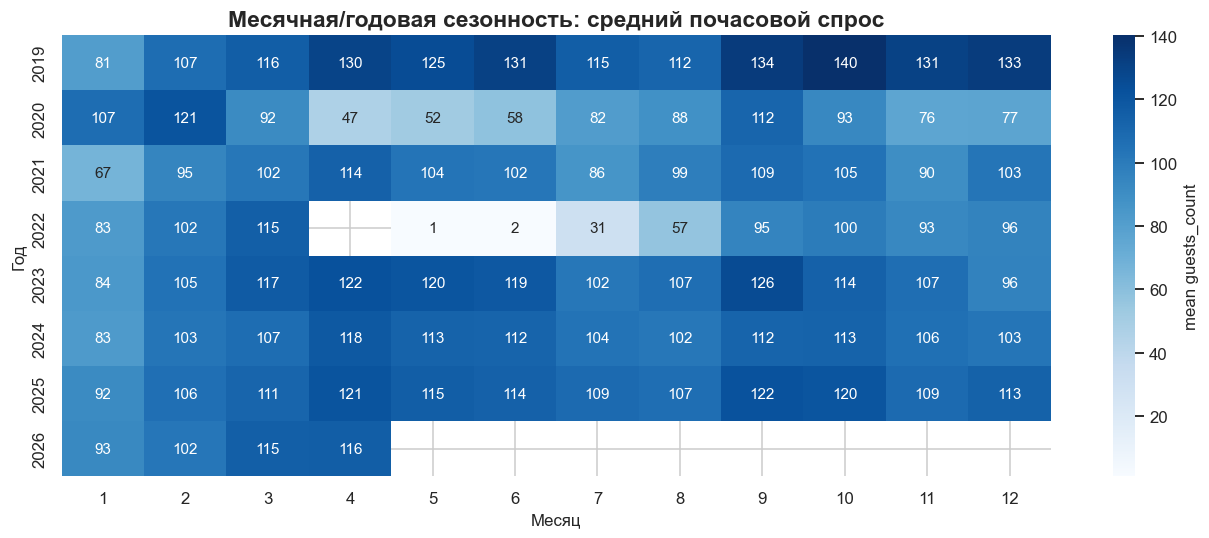

**Вывод.** Год-месяц heatmap показывает долгосрочные сдвиги уровня и месячную сезонность.
Для первой модели это обосновывает признаки `month`, `week_of_year`, `year`, `days_from_start`.

In [5]:
df["day_of_week"] = df["sale_date"].dt.dayofweek
df["weekday_name"] = df["sale_date"].dt.day_name()
df["month"] = df["sale_date"].dt.month
df["year"] = df["sale_date"].dt.year
df["is_weekend"] = df["day_of_week"].isin([5, 6])
df["menu_period"] = np.where(df["sale_hour"].astype(int) < 10, "morning_menu", "main_menu")

hour_stats = df.groupby("sale_hour")["guests_count"].agg(
    mean="mean", median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).reset_index()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hour_stats["sale_hour"], hour_stats["mean"], marker="o", color="#4C78A8", label="mean")
ax.plot(hour_stats["sale_hour"], hour_stats["median"], marker="o", color="#F58518", label="median")
ax.fill_between(hour_stats["sale_hour"], hour_stats["q25"], hour_stats["q75"], color="#4C78A8", alpha=0.16, label="IQR")
ax.set_title("Внутридневная сезонность: средний и медианный спрос по часам")
ax.set_xlabel("Старт часа (`sale_hour`)")
ax.set_ylabel("guests_count")
ax.set_xticks(expected_hours)
ax.legend()
savefig("06_hourly_seasonality.png")
plt.show()
note(f"""
**Вывод.** Самый загруженный час по среднему значению: `{hour_stats.loc[hour_stats['mean'].idxmax(), 'sale_hour']}`.
Самый слабый час: `{hour_stats.loc[hour_stats['mean'].idxmin(), 'sale_hour']}`. Час дня - обязательный признак модели.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="sale_hour", y="guests_count", ax=axes[0], color="#72B7B2", fliersize=1.5)
axes[0].set_title("Разброс спроса по часам")
axes[0].set_xlabel("sale_hour")
axes[0].set_ylabel("guests_count")
weekday_mean = df.groupby("weekday_name")["guests_count"].mean().reindex(DOW_ORDER)
sns.barplot(x=DOW_RU, y=weekday_mean.values, ax=axes[1], color="#F58518")
axes[1].set_title("Средний спрос по дням недели")
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средний guests_count")
savefig("07_hour_boxplot_and_weekday_bar.png")
plt.show()
note("""
**Вывод.** Boxplot показывает, в какие часы ошибка прогноза потенциально дороже из-за большого разброса.
Дни недели заметно различаются, поэтому random split был бы некорректен и сгладил бы недельный паттерн.
""")

pivot_dow_hour = df.pivot_table(index="weekday_name", columns="sale_hour", values="guests_count", aggfunc="mean").reindex(DOW_ORDER)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot_dow_hour, cmap="YlGnBu", linewidths=0.25, linecolor="white", ax=ax, cbar_kws={"label": "mean guests_count"})
ax.set_yticklabels(DOW_RU, rotation=0)
ax.set_title("Heatmap сезонности: день недели × час")
ax.set_xlabel("sale_hour")
ax.set_ylabel("День недели")
savefig("08_heatmap_dow_hour.png")
plt.show()
note("""
**Вывод.** Эта heatmap отвечает на главный вопрос сезонности: спрос зависит не только от часа и не только от дня,
а от их комбинации. Поэтому baseline `day_of_week + sale_hour` является сильной точкой отсчета.
""")

recent_for_heatmap = df[df["sale_date"] >= df["sale_date"].max() - pd.Timedelta(days=59)].copy()
pivot_date_hour = recent_for_heatmap.pivot_table(index="sale_date", columns="sale_hour", values="guests_count", aggfunc="mean")
fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot_date_hour, cmap="viridis", ax=ax, cbar_kws={"label": "guests_count"})
ax.set_title("Дата × час: последние 60 дней истории")
ax.set_xlabel("sale_hour")
ax.set_ylabel("Дата")
ax.set_yticks(np.arange(0, len(pivot_date_hour), 7) + 0.5)
ax.set_yticklabels([d.strftime("%Y-%m-%d") for d in pivot_date_hour.index[::7]], rotation=0)
savefig("09_heatmap_recent_date_hour.png")
plt.show()
note("""
**Вывод.** Heatmap последних дней помогает увидеть локальные пики/провалы перед прогнозным периодом.
Это полезно для выбора recent-baseline и для диагностики, не меняется ли режим спроса прямо перед holdout.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=df, x="sale_hour", y="guests_count", hue="is_weekend", estimator="mean", errorbar=None, marker="o", ax=axes[0], palette=["#4C78A8", "#E45756"])
axes[0].set_title("Будни и выходные: средний профиль по часам")
axes[0].set_xlabel("sale_hour")
axes[0].set_ylabel("mean guests_count")
axes[0].legend(title="is_weekend", labels=["будни", "выходные"])
menu_summary = df.groupby("menu_period")["guests_count"].agg(["mean", "median", "count"]).reindex(["morning_menu", "main_menu"])
sns.barplot(x=menu_summary.index, y=menu_summary["mean"], ax=axes[1], color="#54A24B")
axes[1].set_title("Утреннее меню до 10:00 vs основное меню")
axes[1].set_xlabel("")
axes[1].set_ylabel("mean guests_count")
savefig("10_weekend_and_menu_effects.png")
plt.show()
display(menu_summary)
note("""
**Вывод.** Различие утренних и основных часов подтверждает признак `is_morning_menu`.
Различие будней и выходных подтверждает `is_weekend` и отдельные паттерны по `day_of_week`.
""")

month_year = df.pivot_table(index="year", columns="month", values="guests_count", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(month_year, cmap="Blues", annot=True, fmt=".0f", ax=ax, cbar_kws={"label": "mean guests_count"})
ax.set_title("Месячная/годовая сезонность: средний почасовой спрос")
ax.set_xlabel("Месяц")
ax.set_ylabel("Год")
savefig("11_heatmap_year_month.png")
plt.show()
note("""
**Вывод.** Год-месяц heatmap показывает долгосрочные сдвиги уровня и месячную сезонность.
Для первой модели это обосновывает признаки `month`, `week_of_year`, `year`, `days_from_start`.
""")

## 6. Анализ лагов и автокорреляции

Для почасового ресторанного ряда особенно важны лаги той же точки недели: вчера в тот же час,
неделя назад, две недели назад, четыре недели назад и год назад. Все лаги считаются только из прошлого.

,lag,corr,rows
0,lag_1d,0.849467,40527
1,lag_7d,0.881443,40431
2,lag_14d,0.844059,40319
3,lag_28d,0.808153,40095
4,lag_56d,0.756008,39647
5,lag_91d,0.704627,39087
6,lag_182d,0.683493,37631
7,lag_364d,0.635057,34719


saved: artifacts\figures\12_lag_correlations.png


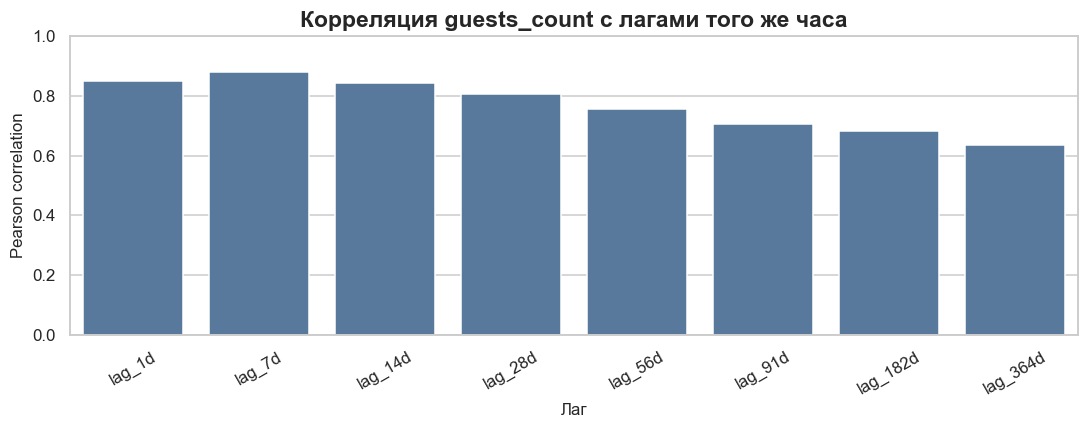

**Вывод.** Сильные недельные/многонедельные лаги означают, что модель должна помнить прошлые значения того же часа.
Если лаги слабые на отдельных периодах, это сигнал о смене режима или внешних факторах.

saved: artifacts\figures\13_daily_acf.png


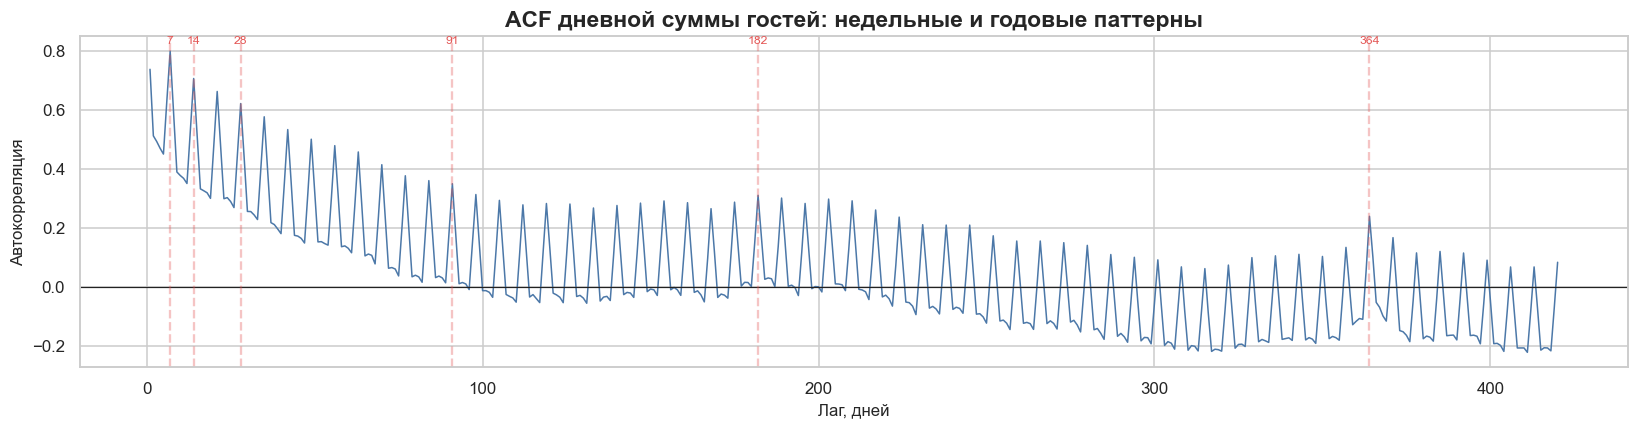

**Вывод.** ACF помогает выбрать лаги не вручную, а по структуре ряда.
Пики около кратных 7 дней подтверждают недельную сезонность, а длинные лаги полезны для годового контекста.

saved: artifacts\figures\14_actual_vs_lags_hexbin.png


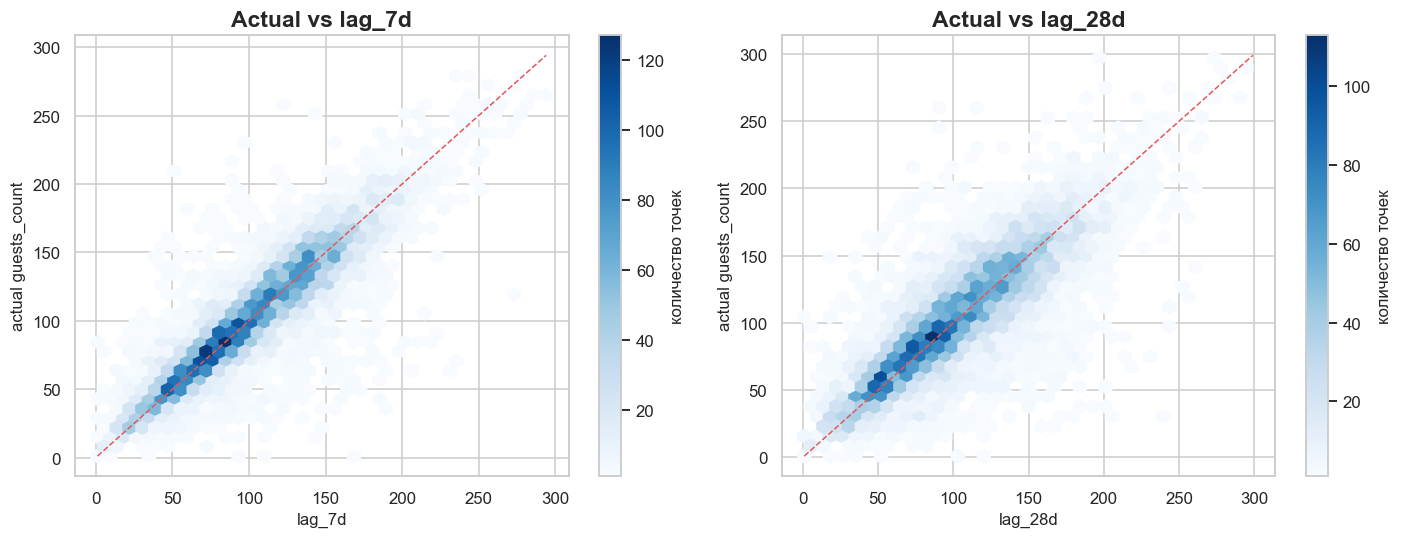

**Вывод.** Чем плотнее облако вдоль диагонали, тем сильнее лаг объясняет текущий спрос.
Отклонения от диагонали показывают часы/периоды, где одного сезонного лага недостаточно.

saved: artifacts\figures\15_recent_weeks_overlay.png


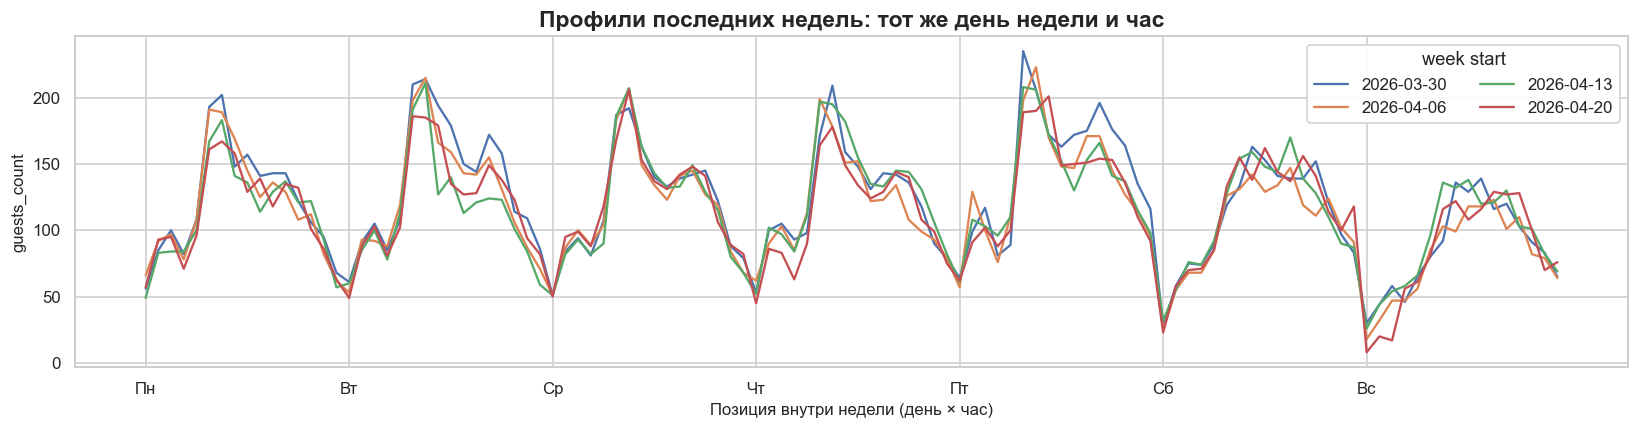

**Вывод.** Наложение последних недель показывает, насколько стабилен недельный профиль прямо перед validation.
Если линии близки, recent seasonal baseline будет трудно побить сложной моделью.

In [6]:
lag_days = [1, 7, 14, 28, 56, 91, 182, 364]
lag_df = df.sort_values(["sale_hour", "sale_date"]).copy()
for lag in lag_days:
    lag_df[f"lag_{lag}d"] = lag_df.groupby("sale_hour")["guests_count"].shift(lag)

lag_corr = []
for lag in lag_days:
    col = f"lag_{lag}d"
    valid = lag_df[["guests_count", col]].dropna()
    corr = valid["guests_count"].corr(valid[col]) if len(valid) else np.nan
    lag_corr.append({"lag": col, "corr": corr, "rows": len(valid)})
lag_corr = pd.DataFrame(lag_corr)
display(lag_corr)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=lag_corr, x="lag", y="corr", ax=ax, color="#4C78A8")
ax.set_title("Корреляция guests_count с лагами того же часа")
ax.set_xlabel("Лаг")
ax.set_ylabel("Pearson correlation")
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, max(1.0, np.nanmax(lag_corr["corr"]) + 0.05))
savefig("12_lag_correlations.png")
plt.show()
note("""
**Вывод.** Сильные недельные/многонедельные лаги означают, что модель должна помнить прошлые значения того же часа.
Если лаги слабые на отдельных периодах, это сигнал о смене режима или внешних факторах.
""")

daily_acf = daily.set_index("sale_date")["guests_sum"].asfreq("D")
acf_df = pd.DataFrame({"lag_days": range(1, 421)})
acf_df["acf"] = [daily_acf.autocorr(lag=int(lag)) for lag in acf_df["lag_days"]]
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(acf_df["lag_days"], acf_df["acf"], color="#4C78A8", linewidth=1.0)
ax.axhline(0, color="#222222", linewidth=0.8)
for x in [7, 14, 28, 91, 182, 364]:
    ax.axvline(x, color="#E45756", linestyle="--", alpha=0.35)
    ax.text(x, ax.get_ylim()[1], str(x), color="#E45756", ha="center", va="top", fontsize=8)
ax.set_title("ACF дневной суммы гостей: недельные и годовые паттерны")
ax.set_xlabel("Лаг, дней")
ax.set_ylabel("Автокорреляция")
savefig("13_daily_acf.png")
plt.show()
note("""
**Вывод.** ACF помогает выбрать лаги не вручную, а по структуре ряда.
Пики около кратных 7 дней подтверждают недельную сезонность, а длинные лаги полезны для годового контекста.
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, lag in zip(axes, [7, 28]):
    col = f"lag_{lag}d"
    sample = lag_df[["guests_count", col]].dropna().sample(min(8000, lag_df[col].notna().sum()), random_state=RANDOM_STATE)
    hb = ax.hexbin(sample[col], sample["guests_count"], gridsize=35, cmap="Blues", mincnt=1)
    lim_min = min(sample[col].min(), sample["guests_count"].min())
    lim_max = max(sample[col].max(), sample["guests_count"].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color="#E45756", linestyle="--", linewidth=1)
    ax.set_title(f"Actual vs lag_{lag}d")
    ax.set_xlabel(col)
    ax.set_ylabel("actual guests_count")
    fig.colorbar(hb, ax=ax, label="количество точек")
savefig("14_actual_vs_lags_hexbin.png")
plt.show()
note("""
**Вывод.** Чем плотнее облако вдоль диагонали, тем сильнее лаг объясняет текущий спрос.
Отклонения от диагонали показывают часы/периоды, где одного сезонного лага недостаточно.
""")

last_monday = df["sale_date"].max() - pd.Timedelta(days=int(df["sale_date"].max().dayofweek))
week_starts = [last_monday - pd.Timedelta(days=7 * i) for i in range(3, -1, -1)]
week_lines = []
for start in week_starts:
    end = start + pd.Timedelta(days=6)
    part = df[df["sale_date"].between(start, end)].copy()
    if part.empty:
        continue
    part["week_start"] = start.strftime("%Y-%m-%d")
    part["position"] = part["sale_date"].dt.dayofweek * len(expected_hours) + (part["sale_hour"] - min_hour)
    week_lines.append(part)
week_cmp = pd.concat(week_lines, ignore_index=True)
fig, ax = plt.subplots(figsize=(15, 4))
sns.lineplot(data=week_cmp, x="position", y="guests_count", hue="week_start", estimator=None, units="week_start", lw=1.5, ax=ax)
ax.set_title("Профили последних недель: тот же день недели и час")
ax.set_xlabel("Позиция внутри недели (день × час)")
ax.set_ylabel("guests_count")
ax.set_xticks([i * len(expected_hours) for i in range(7)])
ax.set_xticklabels(DOW_RU)
ax.legend(title="week start", ncol=2)
savefig("15_recent_weeks_overlay.png")
plt.show()
note("""
**Вывод.** Наложение последних недель показывает, насколько стабилен недельный профиль прямо перед validation.
Если линии близки, recent seasonal baseline будет трудно побить сложной моделью.
""")

## 7. Выбросы и нестабильные периоды

Смотрим максимальные и минимальные дни, почасовые пики и периоды с резкой сменой распределения.

**Топ дней по суммарному спросу**

,sale_date,guests_sum,guests_mean,hours,rolling_7d_mean,rolling_28d_median,rolling_90d_mean
296,2019-10-25,2835,177.1875,16,2264.285714,2268.0,2037.800000
289,2019-10-18,2751,171.9375,16,2258.285714,2268.0,2001.077778
149,2019-05-31,2739,171.1875,16,2249.142857,2219.0,1976.700000
345,2019-12-13,2712,169.5000,16,2252.285714,2158.0,2155.833333
247,2019-09-06,2706,169.1250,16,2196.428571,1909.0,1909.677778
113,2019-04-25,2668,166.7500,16,2224.285714,2160.5,1842.566667
160,2019-06-11,2661,166.3125,16,2268.285714,2394.0,2035.633333
324,2019-11-22,2640,165.0000,16,2189.857143,2168.0,2158.277778
282,2019-10-11,2634,164.6250,16,2175.285714,2248.0,1965.588889
156,2019-06-07,2606,162.8750,16,2268.000000,2350.5,2022.133333


**Минимальные дни по суммарному спросу**

,sale_date,guests_sum,guests_mean,hours,rolling_7d_mean,rolling_28d_median,rolling_90d_mean
1170,2022-05-24,2,1.000000,2,1117.428571,1829.5,1488.688889
1168,2022-03-15,2,1.000000,2,1730.142857,1829.5,1529.555556
1171,2022-06-30,3,1.500000,2,795.285714,1793.5,1471.155556
1169,2022-03-31,3,1.000000,3,1440.428571,1829.5,1510.200000
1172,2022-07-06,8,2.666667,3,518.285714,1793.5,1457.633333
1173,2022-07-24,11,2.750000,4,252.857143,1793.5,1439.600000
1174,2022-07-27,11,5.500000,2,5.714286,1780.5,1420.977778
1184,2022-08-07,406,25.375000,16,710.428571,780.0,1325.555556
454,2020-03-31,410,27.333333,15,851.285714,1375.5,1701.988889
453,2020-03-30,414,27.600000,15,972.142857,1417.0,1705.922222


**Почасовые пики**

,sale_date,sale_hour,guests_count,timestamp,date,day_of_week,weekday_name,month,year,is_weekend,menu_period
3958,2019-09-06,13,299,2019-09-06 13:00:00,2019-09-06,4,Friday,9,2019,False,main_menu
4742,2019-10-25,13,297,2019-10-25 13:00:00,2019-10-25,4,Friday,10,2019,False,main_menu
4630,2019-10-18,13,295,2019-10-18 13:00:00,2019-10-18,4,Friday,10,2019,False,main_menu
4022,2019-09-10,13,294,2019-09-10 13:00:00,2019-09-10,1,Tuesday,9,2019,False,main_menu
4614,2019-10-17,13,291,2019-10-17 13:00:00,2019-10-17,3,Thursday,10,2019,False,main_menu
2486,2019-06-06,13,290,2019-06-06 13:00:00,2019-06-06,3,Thursday,6,2019,False,main_menu
4406,2019-10-04,13,288,2019-10-04 13:00:00,2019-10-04,4,Friday,10,2019,False,main_menu
2502,2019-06-07,13,285,2019-06-07 13:00:00,2019-06-07,4,Friday,6,2019,False,main_menu
3926,2019-09-04,13,284,2019-09-04 13:00:00,2019-09-04,2,Wednesday,9,2019,False,main_menu
4150,2019-09-18,13,284,2019-09-18 13:00:00,2019-09-18,2,Wednesday,9,2019,False,main_menu


saved: artifacts\figures\16_daily_outliers.png


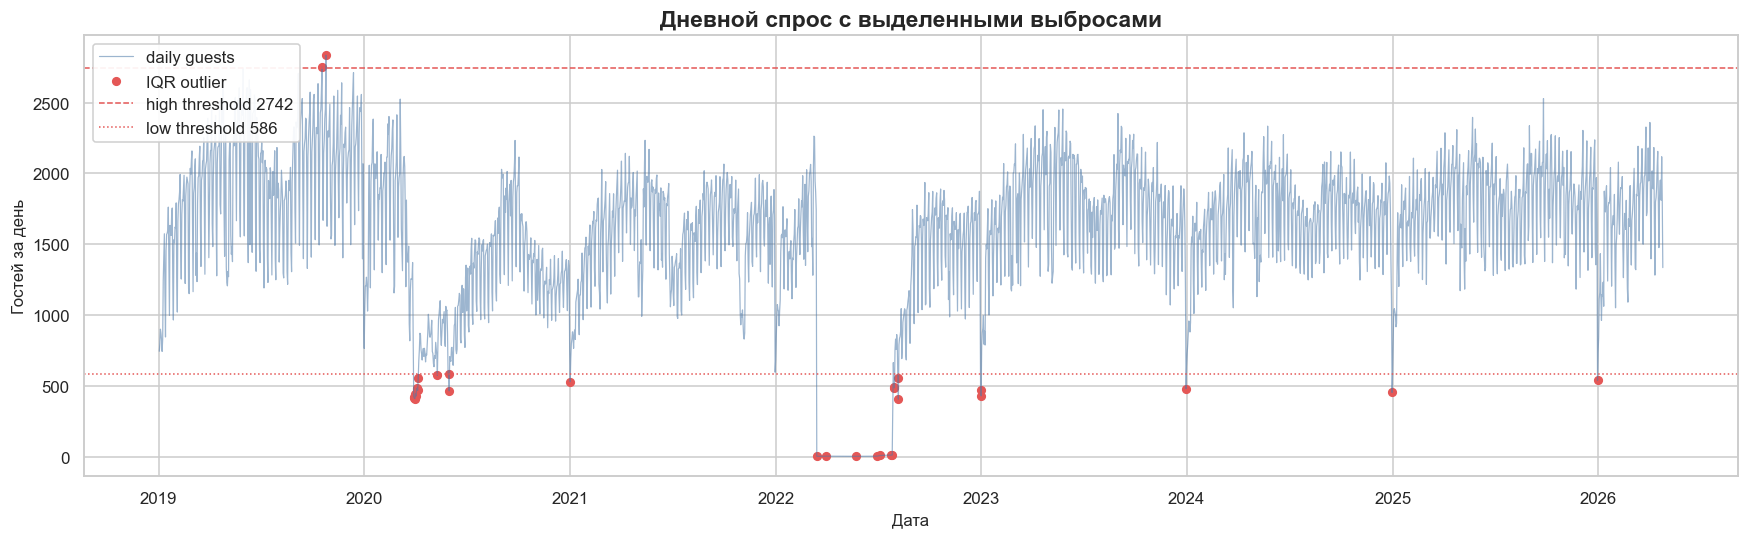

**Вывод.** Дневных IQR-выбросов: `31`.
Их лучше анализировать как события/смены режима, а не просто удалять: для прогноза важно не потерять реальные пики.

saved: artifacts\figures\17_year_distribution_and_hourly_peaks.png


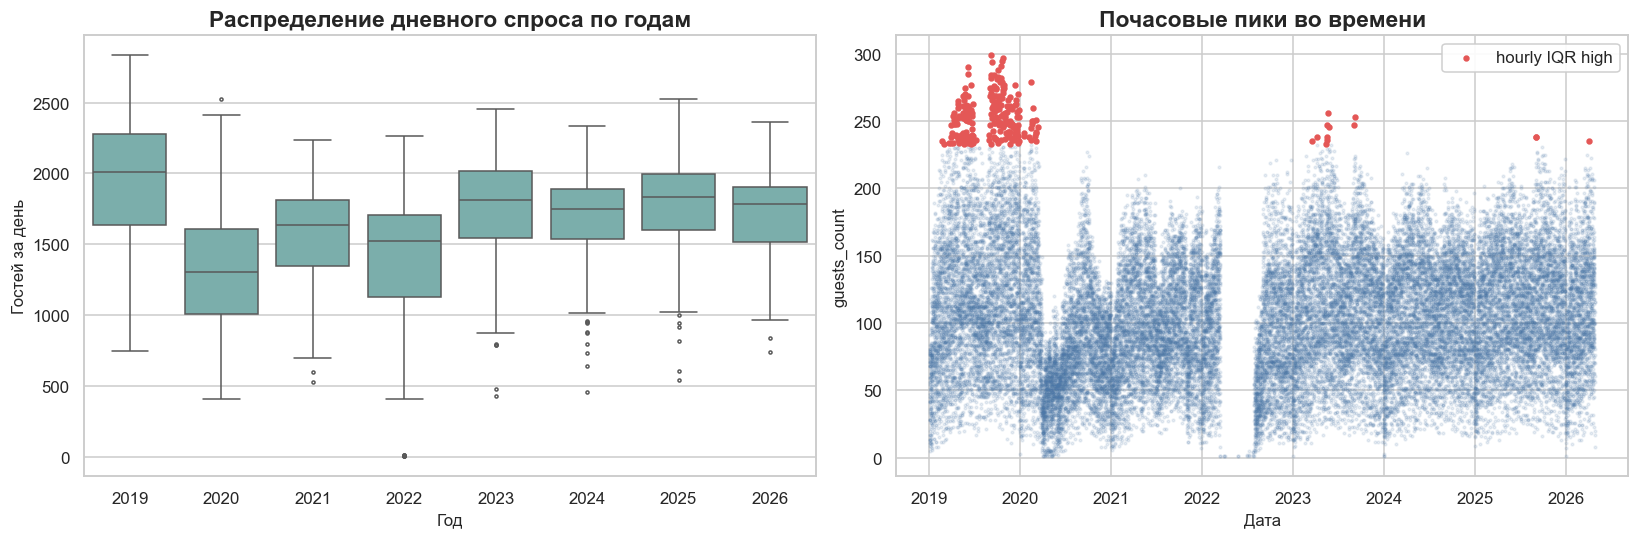

**Вывод.** Сравнение по годам показывает нестабильность распределения, а почасовые пики помогают понять,
где модель будет ошибаться сильнее всего. Для следующих итераций нужны флаги праздников, промо и особых периодов.

In [7]:
top_days = daily.sort_values("guests_sum", ascending=False).head(12)
low_days = daily.sort_values("guests_sum", ascending=True).head(12)
top_hours = df.sort_values("guests_count", ascending=False).head(15)

display(Markdown("**Топ дней по суммарному спросу**"))
display(top_days)
display(Markdown("**Минимальные дни по суммарному спросу**"))
display(low_days)
display(Markdown("**Почасовые пики**"))
display(top_hours)

daily_q1, daily_q3 = daily["guests_sum"].quantile([0.25, 0.75])
daily_iqr = daily_q3 - daily_q1
daily_high = daily_q3 + 1.5 * daily_iqr
daily_low = max(0, daily_q1 - 1.5 * daily_iqr)
daily["is_outlier_iqr"] = (daily["guests_sum"] > daily_high) | (daily["guests_sum"] < daily_low)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily["sale_date"], daily["guests_sum"], linewidth=0.8, color="#4C78A8", alpha=0.55, label="daily guests")
out = daily[daily["is_outlier_iqr"]]
ax.scatter(out["sale_date"], out["guests_sum"], color="#E45756", s=25, label="IQR outlier")
ax.axhline(daily_high, color="#E45756", linestyle="--", linewidth=1, label=f"high threshold {daily_high:.0f}")
ax.axhline(daily_low, color="#E45756", linestyle=":", linewidth=1, label=f"low threshold {daily_low:.0f}")
ax.set_title("Дневной спрос с выделенными выбросами")
ax.set_xlabel("Дата")
ax.set_ylabel("Гостей за день")
format_date_axis(ax)
ax.legend(loc="upper left")
savefig("16_daily_outliers.png")
plt.show()
note(f"""
**Вывод.** Дневных IQR-выбросов: `{int(daily['is_outlier_iqr'].sum())}`.
Их лучше анализировать как события/смены режима, а не просто удалять: для прогноза важно не потерять реальные пики.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=daily.assign(year=daily["sale_date"].dt.year), x="year", y="guests_sum", ax=axes[0], color="#72B7B2", fliersize=2)
axes[0].set_title("Распределение дневного спроса по годам")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("Гостей за день")
hour_outliers = df[df["guests_count"] > high_threshold]
axes[1].scatter(df["timestamp"], df["guests_count"], s=3, alpha=0.12, color="#4C78A8")
axes[1].scatter(hour_outliers["timestamp"], hour_outliers["guests_count"], s=10, color="#E45756", label="hourly IQR high")
axes[1].set_title("Почасовые пики во времени")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("guests_count")
format_date_axis(axes[1])
axes[1].legend()
savefig("17_year_distribution_and_hourly_peaks.png")
plt.show()
note("""
**Вывод.** Сравнение по годам показывает нестабильность распределения, а почасовые пики помогают понять,
где модель будет ошибаться сильнее всего. Для следующих итераций нужны флаги праздников, промо и особых периодов.
""")

## 8. Разбиение train/validation

Random split для временного ряда использовать нельзя: модель увидит будущее распределение и оценка станет
оптимистичной. Правильнее имитировать реальный прогноз будущего: обучаемся на прошлом, валидируемся
на последней неделе. Дополнительно делаем rolling/backtesting по нескольким недельным окнам.

,part,date_start,date_end,rows,days
0,train,2019-01-02,2026-04-19,40431,2536
1,validation,2026-04-20,2026-04-26,112,7


saved: artifacts\figures\18_train_validation_timeline.png


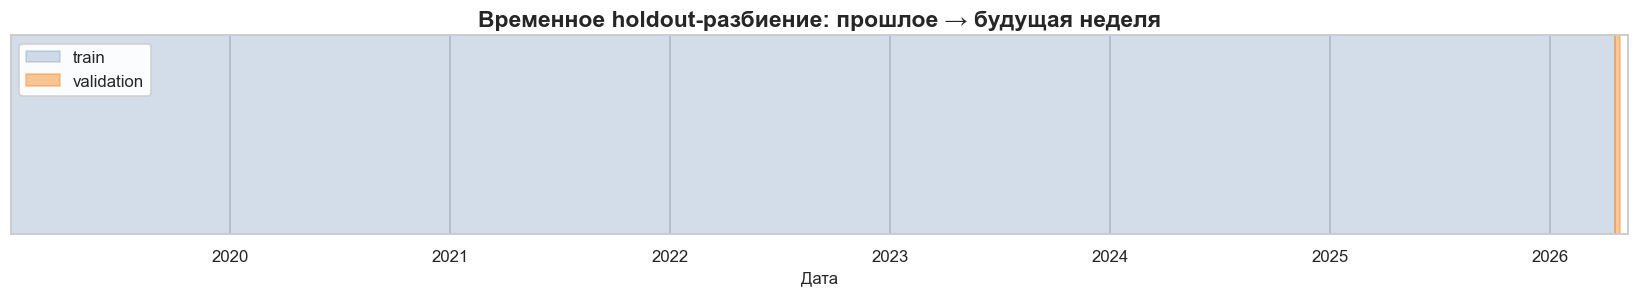

**Вывод.** Validation расположен строго после train, поэтому метрика имитирует реальный прогноз будущей недели.
Random split здесь нельзя: он смешал бы будущие периоды с прошлым и завысил качество.

,fold,val_start,val_end
0,1,2026-03-30,2026-04-05
1,2,2026-04-06,2026-04-12
2,3,2026-04-13,2026-04-19
3,4,2026-04-20,2026-04-26


saved: artifacts\figures\19_backtesting_windows.png


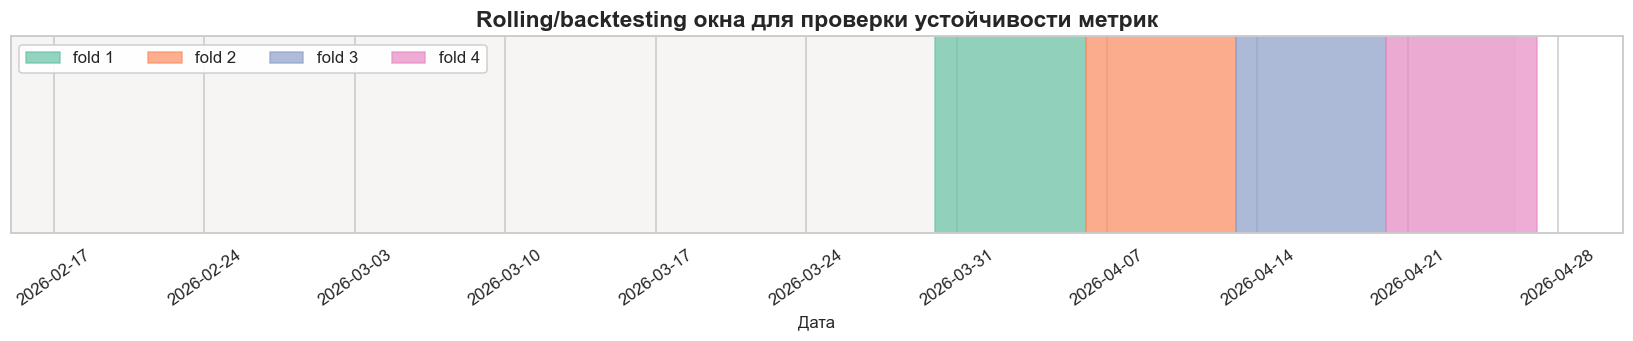

**Вывод.** Основной holdout: `2026-04-20 - 2026-04-26`.
Backtesting-окна нужны, чтобы понять, является ли результат на последней неделе устойчивым или случайным.

In [8]:
unique_dates = np.array(sorted(df["sale_date"].unique()))
validation_dates = unique_dates[-7:]
val_start = pd.Timestamp(validation_dates[0])
val_end = pd.Timestamp(validation_dates[-1])

train_df = df[df["sale_date"] < val_start].copy()
valid_df = df[df["sale_date"].between(val_start, val_end)].copy()

split_summary = pd.DataFrame(
    {
        "part": ["train", "validation"],
        "date_start": [train_df["sale_date"].min().date(), valid_df["sale_date"].min().date()],
        "date_end": [train_df["sale_date"].max().date(), valid_df["sale_date"].max().date()],
        "rows": [len(train_df), len(valid_df)],
        "days": [train_df["sale_date"].nunique(), valid_df["sale_date"].nunique()],
    }
)
display(split_summary)

fig, ax = plt.subplots(figsize=(15, 2.8))
ax.axvspan(train_df["sale_date"].min(), train_df["sale_date"].max(), color="#4C78A8", alpha=0.25, label="train")
ax.axvspan(val_start, val_end + pd.Timedelta(days=1), color="#F58518", alpha=0.45, label="validation")
ax.set_xlim(df["sale_date"].min(), df["sale_date"].max() + pd.Timedelta(days=15))
ax.set_yticks([])
ax.set_title("Временное holdout-разбиение: прошлое → будущая неделя")
ax.set_xlabel("Дата")
format_date_axis(ax)
ax.legend(loc="upper left")
savefig("18_train_validation_timeline.png")
plt.show()
note("""
**Вывод.** Validation расположен строго после train, поэтому метрика имитирует реальный прогноз будущей недели.
Random split здесь нельзя: он смешал бы будущие периоды с прошлым и завысил качество.
""")

backtest_windows = []
for i in range(4, 0, -1):
    end = pd.Timestamp(unique_dates[-1]) - pd.Timedelta(days=7 * (i - 1))
    start = end - pd.Timedelta(days=6)
    if start <= df["sale_date"].min() + pd.Timedelta(days=365):
        continue
    backtest_windows.append({"fold": len(backtest_windows) + 1, "val_start": start, "val_end": end})
bt = pd.DataFrame(backtest_windows)
display(bt)

fig, ax = plt.subplots(figsize=(15, 3.2))
ax.axvspan(df["sale_date"].min(), df["sale_date"].max(), color="#BAB0AC", alpha=0.12)
colors = sns.color_palette("Set2", n_colors=max(len(bt), 1))
for row, color in zip(bt.itertuples(index=False), colors):
    ax.axvspan(row.val_start, row.val_end + pd.Timedelta(days=1), alpha=0.7, color=color, label=f"fold {row.fold}")
ax.set_xlim(df["sale_date"].max() - pd.Timedelta(days=70), df["sale_date"].max() + pd.Timedelta(days=5))
ax.set_yticks([])
ax.set_title("Rolling/backtesting окна для проверки устойчивости метрик")
ax.set_xlabel("Дата")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=35)
ax.legend(loc="upper left", ncol=4)
savefig("19_backtesting_windows.png")
plt.show()
note(f"""
**Вывод.** Основной holdout: `{val_start.date()} - {val_end.date()}`.
Backtesting-окна нужны, чтобы понять, является ли результат на последней неделе устойчивым или случайным.
""")

## 9. Baseline-модели

Строим несколько простых сезонных baseline: median/mean по `day_of_week + sale_hour`,
seasonal naive `lag_7d` и recent median за последние N недель. Их нужно побить ML-моделью.

,model,MAE,RMSE,WAPE,SMAPE
3,recent_8w_median_dow_hour,8.941964,11.474058,7.841372,9.615768
0,median_dow_hour,11.308036,14.476351,9.916223,12.453060
2,seasonal_naive_lag_7d,12.089286,15.389584,10.601315,12.684851
1,mean_dow_hour,12.698880,15.815207,11.135880,13.775504


saved: artifacts\figures\20_actual_vs_best_baseline.png


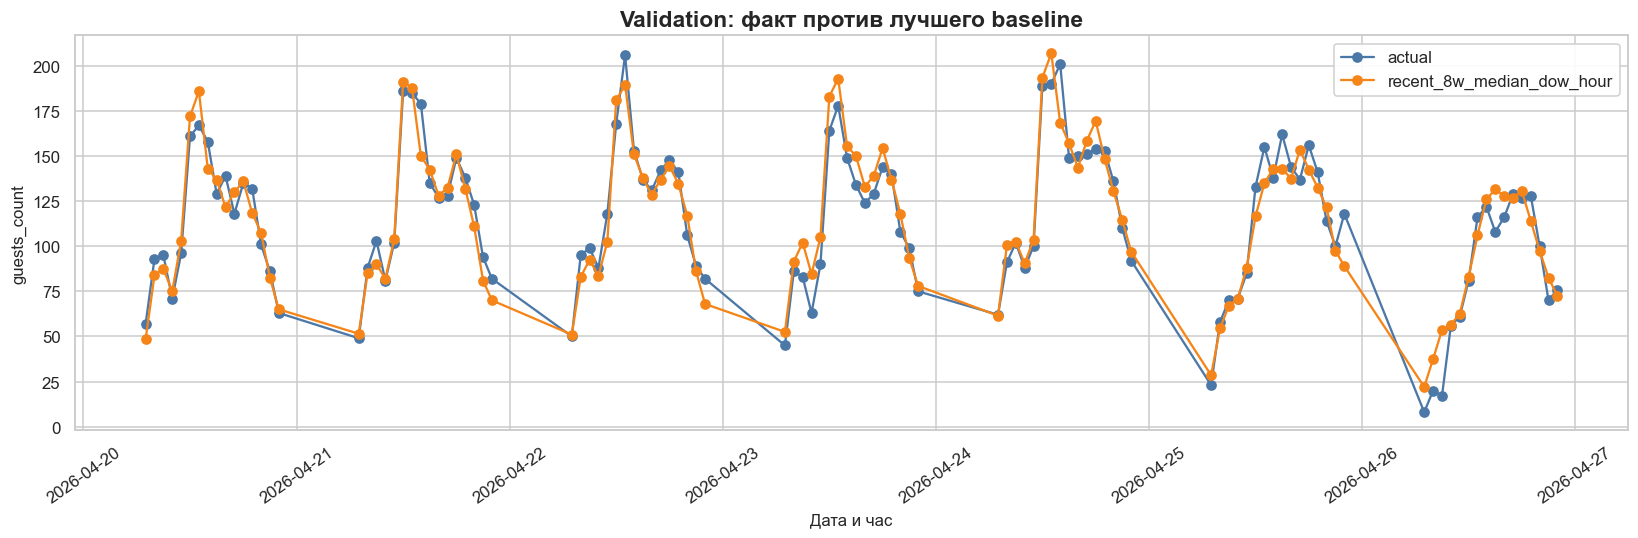

**Вывод.** Лучший baseline: `recent_8w_median_dow_hour`, WAPE = `7.84%`.
Этот график показывает, где простая сезонная логика уже достаточно хорошо повторяет форму недели.

saved: artifacts\figures\21_baseline_errors_by_hour_weekday.png


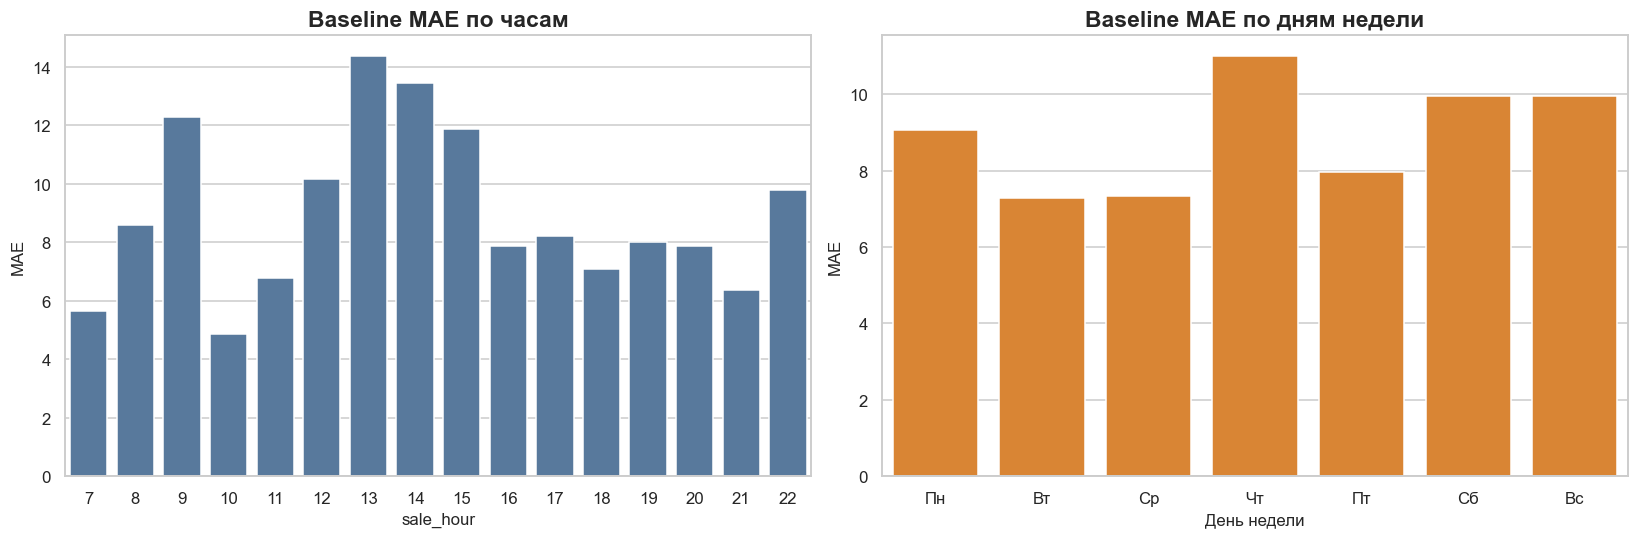

**Вывод.** Ошибки по часам и дням недели показывают, где baseline недоучитывает структуру спроса.
Именно эти срезы должны улучшаться после добавления лагов, rolling-признаков и внешних календарей.

saved: artifacts\figures\22_baseline_error_heatmap.png


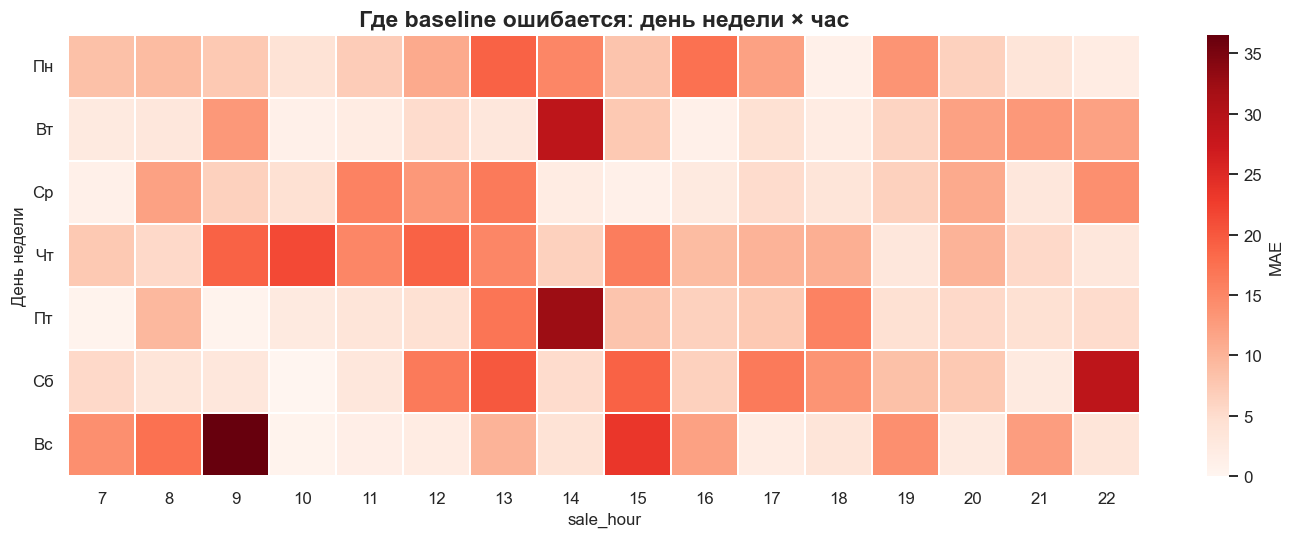

**Вывод.** Error heatmap превращает метрику в план работ: красные зоны показывают конкретные часы,
где нужны дополнительные признаки или более гибкая модель.

saved: artifacts\figures\23_baseline_metrics_comparison.png


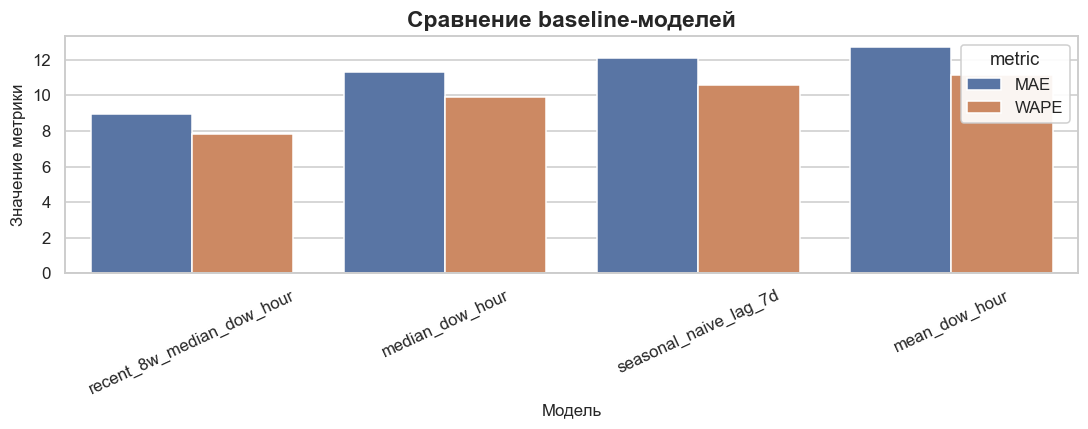

**Вывод.** Сильный recent-baseline означает, что для защиты важно не просто обучить ML,
а показать, что он стабильно выигрывает у простого сезонного правила на честном временном split.

In [9]:
def add_calendar_basic(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["day_of_week"] = out["sale_date"].dt.dayofweek
    out["weekday_name"] = out["sale_date"].dt.day_name()
    out["month"] = out["sale_date"].dt.month
    return out

train_base = add_calendar_basic(train_df)
valid_base = add_calendar_basic(valid_df)

global_median = train_base["guests_count"].median()
median_map = train_base.groupby(["day_of_week", "sale_hour"])["guests_count"].median()
mean_map = train_base.groupby(["day_of_week", "sale_hour"])["guests_count"].mean()


def map_dow_hour(valid: pd.DataFrame, mapping: pd.Series, fallback: float) -> np.ndarray:
    idx = pd.MultiIndex.from_frame(valid[["day_of_week", "sale_hour"]])
    return mapping.reindex(idx).fillna(fallback).to_numpy()


baseline_preds = {}
baseline_preds["median_dow_hour"] = map_dow_hour(valid_base, median_map, global_median)
baseline_preds["mean_dow_hour"] = map_dow_hour(valid_base, mean_map, train_base["guests_count"].mean())

hist_lookup = train_base.set_index(["sale_date", "sale_hour"])["guests_count"]
lag7_values = []
for row in valid_base.itertuples(index=False):
    key = (row.sale_date - pd.Timedelta(days=7), row.sale_hour)
    lag7_values.append(hist_lookup.get(key, global_median))
baseline_preds["seasonal_naive_lag_7d"] = np.array(lag7_values, dtype=float)

recent_weeks = 8
recent_start = val_start - pd.Timedelta(days=7 * recent_weeks)
recent_train = train_base[train_base["sale_date"] >= recent_start]
recent_map = recent_train.groupby(["day_of_week", "sale_hour"])["guests_count"].median()
baseline_preds[f"recent_{recent_weeks}w_median_dow_hour"] = map_dow_hour(valid_base, recent_map, global_median)

baseline_metrics = []
for name, pred in baseline_preds.items():
    baseline_metrics.append({"model": name, **regression_metrics(valid_base["guests_count"], pred)})
baseline_metrics = pd.DataFrame(baseline_metrics).sort_values("WAPE")
baseline_metrics.to_csv(REPORT_DIR / "baseline_metrics.csv", index=False)
display(baseline_metrics)

best_baseline_name = baseline_metrics.iloc[0]["model"]
valid_plot = valid_base.copy()
valid_plot["prediction"] = baseline_preds[best_baseline_name]
valid_plot["residual"] = valid_plot["guests_count"] - valid_plot["prediction"]
valid_plot["abs_error"] = valid_plot["residual"].abs()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(valid_plot["timestamp"], valid_plot["guests_count"], marker="o", linewidth=1.5, label="actual", color="#4C78A8")
ax.plot(valid_plot["timestamp"], valid_plot["prediction"], marker="o", linewidth=1.5, label=best_baseline_name, color="#F58518")
ax.set_title("Validation: факт против лучшего baseline")
ax.set_xlabel("Дата и час")
ax.set_ylabel("guests_count")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=35)
ax.legend()
savefig("20_actual_vs_best_baseline.png")
plt.show()
note(f"""
**Вывод.** Лучший baseline: `{best_baseline_name}`, WAPE = `{baseline_metrics.iloc[0]['WAPE']:.2f}%`.
Этот график показывает, где простая сезонная логика уже достаточно хорошо повторяет форму недели.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=valid_plot, x="sale_hour", y="abs_error", estimator="mean", errorbar=None, ax=axes[0], color="#4C78A8")
axes[0].set_title("Baseline MAE по часам")
axes[0].set_xlabel("sale_hour")
axes[0].set_ylabel("MAE")
sns.barplot(data=valid_plot, x="weekday_name", y="abs_error", order=DOW_ORDER, estimator="mean", errorbar=None, ax=axes[1], color="#F58518")
axes[1].set_title("Baseline MAE по дням недели")
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("MAE")
axes[1].set_xticklabels(DOW_RU)
savefig("21_baseline_errors_by_hour_weekday.png")
plt.show()
note("""
**Вывод.** Ошибки по часам и дням недели показывают, где baseline недоучитывает структуру спроса.
Именно эти срезы должны улучшаться после добавления лагов, rolling-признаков и внешних календарей.
""")

error_heatmap = valid_plot.pivot_table(index="weekday_name", columns="sale_hour", values="abs_error", aggfunc="mean").reindex(DOW_ORDER)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(error_heatmap, cmap="Reds", linewidths=0.25, linecolor="white", ax=ax, cbar_kws={"label": "MAE"})
ax.set_title("Где baseline ошибается: день недели × час")
ax.set_yticklabels(DOW_RU, rotation=0)
ax.set_xlabel("sale_hour")
ax.set_ylabel("День недели")
savefig("22_baseline_error_heatmap.png")
plt.show()
note("""
**Вывод.** Error heatmap превращает метрику в план работ: красные зоны показывают конкретные часы,
где нужны дополнительные признаки или более гибкая модель.
""")

fig, ax = plt.subplots(figsize=(10, 4))
plot_metrics = baseline_metrics.melt(id_vars="model", value_vars=["MAE", "WAPE"], var_name="metric", value_name="value")
sns.barplot(data=plot_metrics, x="model", y="value", hue="metric", ax=ax)
ax.set_title("Сравнение baseline-моделей")
ax.set_xlabel("Модель")
ax.set_ylabel("Значение метрики")
ax.tick_params(axis="x", rotation=25)
savefig("23_baseline_metrics_comparison.png")
plt.show()
note("""
**Вывод.** Сильный recent-baseline означает, что для защиты важно не просто обучить ML,
а показать, что он стабильно выигрывает у простого сезонного правила на честном временном split.
""")

## 10. Feature engineering plan

Создаем календарные, циклические, лаговые и rolling-признаки. Ключевой принцип: все лаги и rolling
считаются только из прошлого через `shift`. Для будущей недели признаки считаются только из истории,
доступной до начала прогноза, чтобы избежать data leakage.

In [10]:
LAG_DAYS = [1, 7, 14, 28, 56, 91, 182, 364]
ROLL_WINDOWS = [7, 14, 28]

def add_calendar_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["sale_hour"] = out["sale_hour"].astype(int)
    out["day_of_week"] = out["sale_date"].dt.dayofweek
    out["day_of_month"] = out["sale_date"].dt.day
    out["day_of_year"] = out["sale_date"].dt.dayofyear
    out["week_of_year"] = out["sale_date"].dt.isocalendar().week.astype(int)
    out["month"] = out["sale_date"].dt.month
    out["quarter"] = out["sale_date"].dt.quarter
    out["year"] = out["sale_date"].dt.year
    out["is_weekend"] = out["day_of_week"].isin([5, 6]).astype(int)
    out["is_morning_menu"] = (out["sale_hour"] < 10).astype(int)
    out["is_main_menu"] = (out["sale_hour"] >= 10).astype(int)
    out["hour_sin"] = np.sin(2 * np.pi * out["sale_hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["sale_hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week"] / 7)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["days_from_start"] = (out["sale_date"] - df["sale_date"].min()).dt.days
    out["is_covid_period"] = out["sale_date"].between("2020-03-15", "2021-06-30").astype(int)
    out["is_after_rebrand"] = (out["sale_date"] >= pd.Timestamp("2022-06-12")).astype(int)
    return out

def add_past_features_for_training(data: pd.DataFrame) -> pd.DataFrame:
    out = add_calendar_features(data).sort_values(["sale_hour", "sale_date"]).copy()
    grp = out.groupby("sale_hour", group_keys=False)
    for lag in LAG_DAYS:
        out[f"lag_{lag}d"] = grp["guests_count"].shift(lag)
    shifted = grp["guests_count"].shift(1)
    out["rolling_7d_mean"] = shifted.groupby(out["sale_hour"]).rolling(7, min_periods=3).mean().reset_index(level=0, drop=True)
    out["rolling_14d_mean"] = shifted.groupby(out["sale_hour"]).rolling(14, min_periods=5).mean().reset_index(level=0, drop=True)
    out["rolling_28d_mean"] = shifted.groupby(out["sale_hour"]).rolling(28, min_periods=7).mean().reset_index(level=0, drop=True)
    out["rolling_7d_median"] = shifted.groupby(out["sale_hour"]).rolling(7, min_periods=3).median().reset_index(level=0, drop=True)
    out["rolling_28d_std"] = shifted.groupby(out["sale_hour"]).rolling(28, min_periods=7).std().reset_index(level=0, drop=True)
    out["rolling_28d_min"] = shifted.groupby(out["sale_hour"]).rolling(28, min_periods=7).min().reset_index(level=0, drop=True)
    out["rolling_28d_max"] = shifted.groupby(out["sale_hour"]).rolling(28, min_periods=7).max().reset_index(level=0, drop=True)
    out["diff_7d"] = out["lag_7d"] - out["lag_14d"]
    out["diff_28d"] = out["lag_28d"] - out["lag_56d"]
    return out.sort_values(["sale_date", "sale_hour"]).reset_index(drop=True)

def add_past_features_from_history(target: pd.DataFrame, history: pd.DataFrame) -> pd.DataFrame:
    out = add_calendar_features(target).sort_values(["sale_date", "sale_hour"]).copy()
    hist = history.sort_values(["sale_date", "sale_hour"]).copy()
    lookup = hist.set_index(["sale_date", "sale_hour"])["guests_count"]
    for lag in LAG_DAYS:
        values = []
        for row in out.itertuples(index=False):
            values.append(lookup.get((row.sale_date - pd.Timedelta(days=lag), row.sale_hour), np.nan))
        out[f"lag_{lag}d"] = values

    hist_by_hour = {hour: part.sort_values("sale_date") for hour, part in hist.groupby("sale_hour")}
    for idx, row in out.iterrows():
        part = hist_by_hour.get(row["sale_hour"])
        if part is None:
            continue
        past = part[part["sale_date"] < row["sale_date"]]
        for window in ROLL_WINDOWS:
            vals = past.tail(window)["guests_count"]
            if len(vals) >= max(3, min(window, 7)):
                out.loc[idx, f"rolling_{window}d_mean"] = vals.mean()
        vals7 = past.tail(7)["guests_count"]
        vals28 = past.tail(28)["guests_count"]
        if len(vals7) >= 3:
            out.loc[idx, "rolling_7d_median"] = vals7.median()
        if len(vals28) >= 7:
            out.loc[idx, "rolling_28d_std"] = vals28.std()
            out.loc[idx, "rolling_28d_min"] = vals28.min()
            out.loc[idx, "rolling_28d_max"] = vals28.max()

    out["diff_7d"] = out["lag_7d"] - out["lag_14d"]
    out["diff_28d"] = out["lag_28d"] - out["lag_56d"]
    return out.sort_values(["sale_date", "sale_hour"]).reset_index(drop=True)

train_feat = add_past_features_for_training(train_df)
valid_feat = add_past_features_from_history(valid_df, train_df)

calendar_features = [
    "sale_hour", "day_of_week", "day_of_month", "day_of_year", "week_of_year",
    "month", "quarter", "year", "is_weekend", "is_morning_menu", "is_main_menu",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "days_from_start", "is_covid_period", "is_after_rebrand",
]
lag_features = [f"lag_{lag}d" for lag in LAG_DAYS] + ["diff_7d", "diff_28d"]
rolling_features = [
    "rolling_7d_mean", "rolling_14d_mean", "rolling_28d_mean",
    "rolling_7d_median", "rolling_28d_std", "rolling_28d_min", "rolling_28d_max",
]

feature_preview = train_feat[calendar_features + lag_features + rolling_features].head(10)
display(feature_preview)
display(pd.DataFrame({"feature": calendar_features + lag_features + rolling_features}))

display(Markdown(
    """
    **Вывод по признакам и leakage.** Для обучения лаги строятся через `groupby(sale_hour).shift(lag)`,
    поэтому текущий `guests_count` не попадает в свои же признаки. Для validation и будущего прогноза
    признаки считаются отдельной функцией только из `history`, то есть из данных до начала прогнозного окна.
    `diff_7d` и `diff_28d` тоже безопасны: это разности прошлых лагов (`lag_7d - lag_14d`,
    `lag_28d - lag_56d`), а не разность с текущим таргетом.
    """
))

,sale_hour,day_of_week,day_of_month,day_of_year,week_of_year,month,quarter,year,is_weekend,is_morning_menu,...,lag_364d,diff_7d,diff_28d,rolling_7d_mean,rolling_14d_mean,rolling_28d_mean,rolling_7d_median,rolling_28d_std,rolling_28d_min,rolling_28d_max
0,7,2,2,2,1,1,1,2019,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8,2,2,2,1,1,1,2019,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9,2,2,2,1,1,1,2019,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10,2,2,2,1,1,1,2019,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11,2,2,2,1,1,1,2019,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,12,2,2,2,1,1,1,2019,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,13,2,2,2,1,1,1,2019,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,14,2,2,2,1,1,1,2019,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,15,2,2,2,1,1,1,2019,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,16,2,2,2,1,1,1,2019,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,feature
0,sale_hour
1,day_of_week
2,day_of_month
3,day_of_year
4,week_of_year
5,month
6,quarter
7,year
8,is_weekend
9,is_morning_menu



    **Вывод по признакам и leakage.** Для обучения лаги строятся через `groupby(sale_hour).shift(lag)`,
    поэтому текущий `guests_count` не попадает в свои же признаки. Для validation и будущего прогноза
    признаки считаются отдельной функцией только из `history`, то есть из данных до начала прогнозного окна.
    `diff_7d` и `diff_28d` тоже безопасны: это разности прошлых лагов (`lag_7d - lag_14d`,
    `lag_28d - lag_56d`), а не разность с текущим таргетом.
    

## 11. Первая ML-модель

Обучаем LightGBM без внешних данных. Сравниваем три набора признаков:
календарные, календарные + лаги, календарные + лаги + rolling.

,model,MAE,RMSE,WAPE,SMAPE
0,calendar,9.779844,12.665952,8.576123,10.784128
2,calendar_lags_rolling,32.582863,37.809854,28.572508,33.710654
1,calendar_lags,47.472213,55.104111,41.629251,51.167023


,model,MAE,RMSE,WAPE,SMAPE,type
0,recent_8w_median_dow_hour,8.941964,11.474058,7.841372,9.615768,baseline
4,calendar,9.779844,12.665952,8.576123,10.784128,ml
1,median_dow_hour,11.308036,14.476351,9.916223,12.453060,baseline
2,seasonal_naive_lag_7d,12.089286,15.389584,10.601315,12.684851,baseline
3,mean_dow_hour,12.698880,15.815207,11.135880,13.775504,baseline
5,calendar_lags_rolling,32.582863,37.809854,28.572508,33.710654,ml
6,calendar_lags,47.472213,55.104111,41.629251,51.167023,ml


saved: artifacts\figures\24_actual_vs_ml_prediction.png


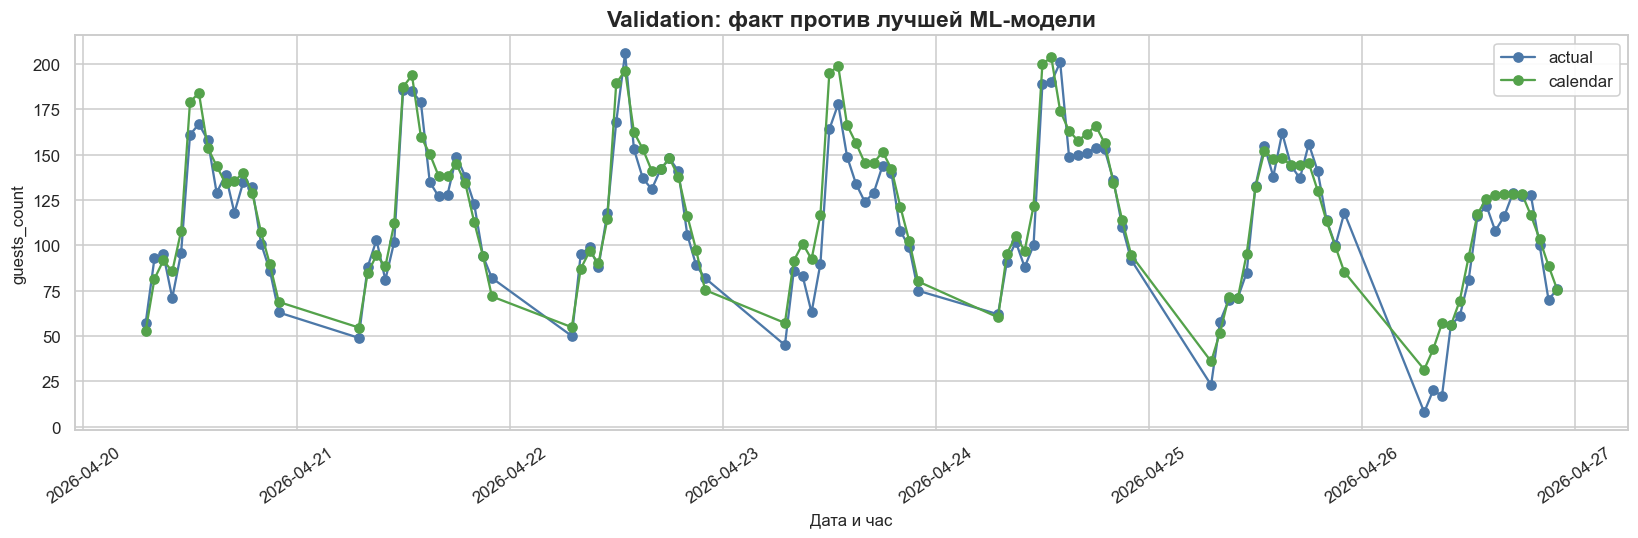

**Вывод.** Лучшая ML-модель: `calendar`, WAPE = `8.58%`.
График нужен, чтобы увидеть не только среднюю ошибку, но и форму: попадает ли модель в пики и провалы недели.

saved: artifacts\figures\25_ml_residual_diagnostics.png


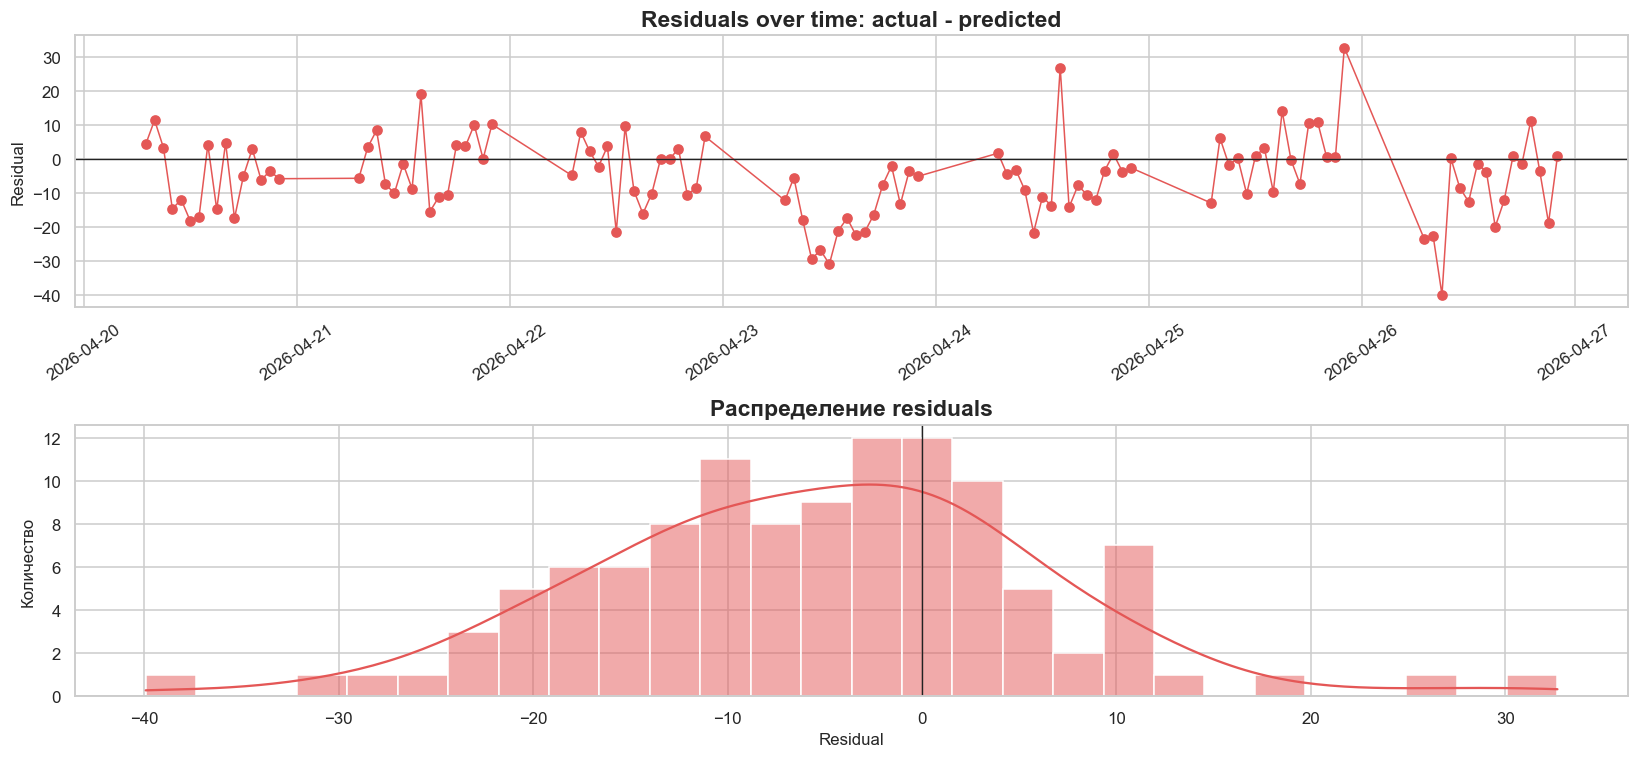

**Вывод.** Residual plot показывает смещение во времени: если ошибки подряд одного знака,
модель не поймала локальный уровень спроса. Histogram показывает, есть ли систематический bias.

saved: artifacts\figures\26_ml_errors_by_hour_weekday.png


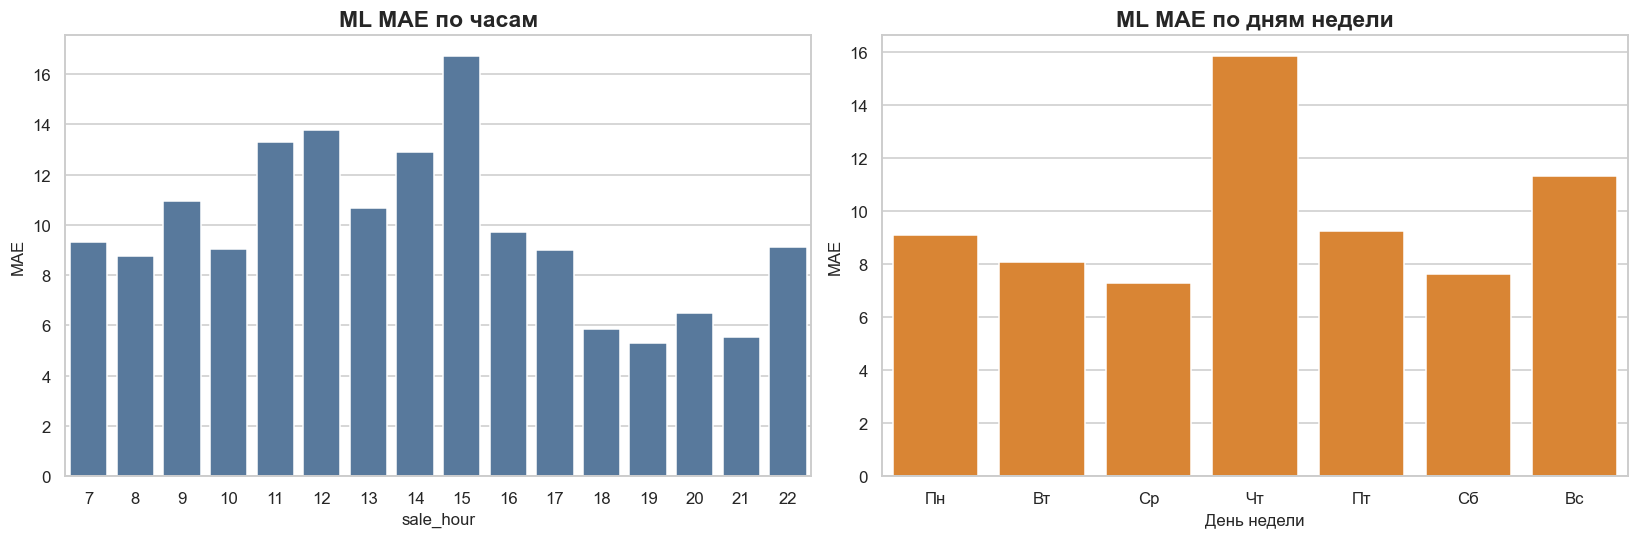

**Вывод.** Эти срезы отвечают на практический вопрос: в какие часы и дни ML-модель остается слабой.
Их удобно сравнивать с baseline error heatmap, чтобы понять, где ML реально добавляет ценность.

saved: artifacts\figures\27_ml_error_heatmap.png


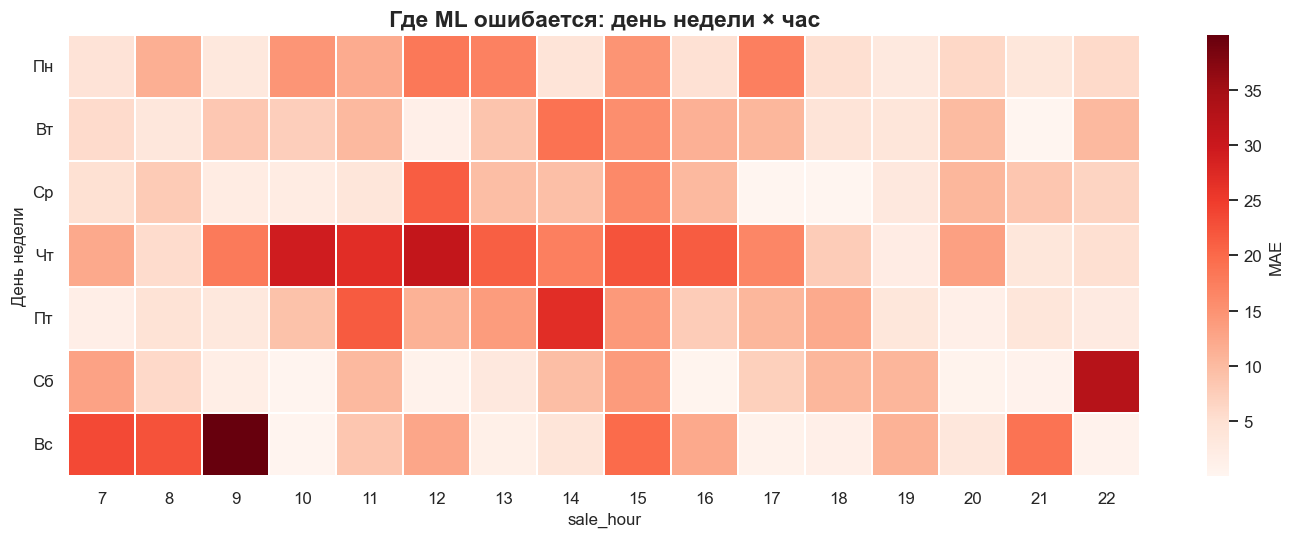

,feature,importance
17,days_from_start,3266
3,day_of_year,2957
0,sale_hour,1889
2,day_of_month,1480
1,day_of_week,1090
4,week_of_year,749
7,year,661
12,hour_cos,641
16,month_cos,490
13,dow_sin,359


saved: artifacts\figures\28_feature_importance_and_model_comparison.png


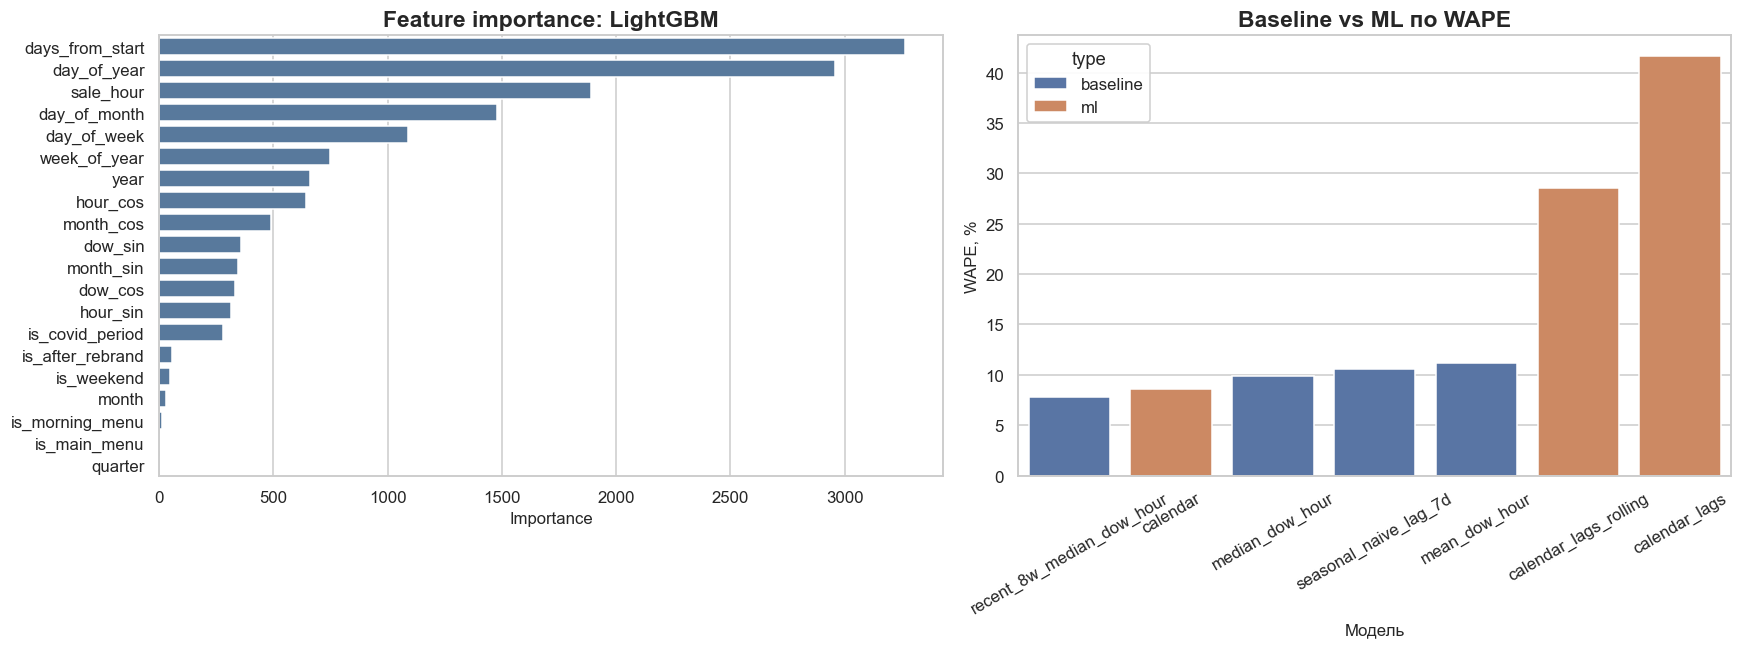

**Вывод по модели.** Лучший baseline `recent_8w_median_dow_hour`: WAPE `7.84%`.
Лучшая ML-модель `calendar`: WAPE `8.58%`.
Если ML хуже baseline, это не провал EDA, а важный результат: текущих train.csv-based признаков недостаточно,
и production-модель нужно дорабатывать в исходном ML-коде, а не дублировать логику в ноутбуке.

In [11]:
feature_sets = {
    "calendar": calendar_features,
    "calendar_lags": calendar_features + lag_features,
    "calendar_lags_rolling": calendar_features + lag_features + rolling_features,
}

ml_metrics = []
ml_predictions = {}
fitted_models = {}

for name, features in feature_sets.items():
    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.035,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_samples=30,
        random_state=RANDOM_STATE,
        verbose=-1,
    )
    X_train = train_feat[features]
    y_train = train_feat["guests_count"]
    X_valid = valid_feat[features]
    y_valid = valid_feat["guests_count"]
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_valid), 0, None)
    ml_predictions[name] = pred
    fitted_models[name] = model
    ml_metrics.append({"model": name, **regression_metrics(y_valid, pred)})

ml_metrics = pd.DataFrame(ml_metrics).sort_values("WAPE")
ml_metrics.to_csv(REPORT_DIR / "ml_metrics.csv", index=False)
display(ml_metrics)

comparison = pd.concat(
    [baseline_metrics.assign(type="baseline"), ml_metrics.assign(type="ml")],
    ignore_index=True,
).sort_values("WAPE")
display(comparison)

best_ml_name = ml_metrics.iloc[0]["model"]
best_model = fitted_models[best_ml_name]
best_features = feature_sets[best_ml_name]
valid_ml = valid_feat.copy()
valid_ml["prediction"] = ml_predictions[best_ml_name]
valid_ml["residual"] = valid_ml["guests_count"] - valid_ml["prediction"]
valid_ml["abs_error"] = valid_ml["residual"].abs()
valid_ml["weekday_name"] = valid_ml["sale_date"].dt.day_name()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(valid_ml["timestamp"], valid_ml["guests_count"], marker="o", linewidth=1.5, label="actual", color="#4C78A8")
ax.plot(valid_ml["timestamp"], valid_ml["prediction"], marker="o", linewidth=1.5, label=best_ml_name, color="#54A24B")
ax.set_title("Validation: факт против лучшей ML-модели")
ax.set_xlabel("Дата и час")
ax.set_ylabel("guests_count")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=35)
ax.legend()
savefig("24_actual_vs_ml_prediction.png")
plt.show()
note(f"""
**Вывод.** Лучшая ML-модель: `{best_ml_name}`, WAPE = `{ml_metrics.iloc[0]['WAPE']:.2f}%`.
График нужен, чтобы увидеть не только среднюю ошибку, но и форму: попадает ли модель в пики и провалы недели.
""")

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=False)
axes[0].plot(valid_ml["timestamp"], valid_ml["residual"], marker="o", linewidth=1, color="#E45756")
axes[0].axhline(0, color="#222222", linewidth=0.9)
axes[0].set_title("Residuals over time: actual - predicted")
axes[0].set_ylabel("Residual")
axes[0].xaxis.set_major_locator(mdates.DayLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[0].tick_params(axis="x", rotation=35)
sns.histplot(valid_ml["residual"], bins=28, kde=True, ax=axes[1], color="#E45756")
axes[1].axvline(0, color="#222222", linewidth=0.9)
axes[1].set_title("Распределение residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Количество")
savefig("25_ml_residual_diagnostics.png")
plt.show()
note("""
**Вывод.** Residual plot показывает смещение во времени: если ошибки подряд одного знака,
модель не поймала локальный уровень спроса. Histogram показывает, есть ли систематический bias.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=valid_ml, x="sale_hour", y="abs_error", estimator="mean", errorbar=None, ax=axes[0], color="#4C78A8")
axes[0].set_title("ML MAE по часам")
axes[0].set_xlabel("sale_hour")
axes[0].set_ylabel("MAE")
sns.barplot(data=valid_ml, x="weekday_name", y="abs_error", order=DOW_ORDER, estimator="mean", errorbar=None, ax=axes[1], color="#F58518")
axes[1].set_title("ML MAE по дням недели")
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("MAE")
axes[1].set_xticklabels(DOW_RU)
savefig("26_ml_errors_by_hour_weekday.png")
plt.show()
note("""
**Вывод.** Эти срезы отвечают на практический вопрос: в какие часы и дни ML-модель остается слабой.
Их удобно сравнивать с baseline error heatmap, чтобы понять, где ML реально добавляет ценность.
""")

ml_error_heatmap = valid_ml.pivot_table(index="weekday_name", columns="sale_hour", values="abs_error", aggfunc="mean").reindex(DOW_ORDER)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(ml_error_heatmap, cmap="Reds", linewidths=0.25, linecolor="white", ax=ax, cbar_kws={"label": "MAE"})
ax.set_title("Где ML ошибается: день недели × час")
ax.set_yticklabels(DOW_RU, rotation=0)
ax.set_xlabel("sale_hour")
ax.set_ylabel("День недели")
savefig("27_ml_error_heatmap.png")
plt.show()

importance = pd.DataFrame({"feature": best_features, "importance": best_model.feature_importances_}).sort_values("importance", ascending=False)
importance.to_csv(REPORT_DIR / "feature_importance.csv", index=False)
display(importance.head(30))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.1, 1]})
sns.barplot(data=importance.head(25), x="importance", y="feature", ax=axes[0], color="#4C78A8")
axes[0].set_title("Feature importance: LightGBM")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")
plot_compare = comparison.head(8).copy()
sns.barplot(data=plot_compare, x="model", y="WAPE", hue="type", dodge=False, ax=axes[1])
axes[1].set_title("Baseline vs ML по WAPE")
axes[1].set_xlabel("Модель")
axes[1].set_ylabel("WAPE, %")
axes[1].tick_params(axis="x", rotation=30)
savefig("28_feature_importance_and_model_comparison.png")
plt.show()

best_baseline_wape = baseline_metrics.iloc[0]["WAPE"]
best_ml_wape = ml_metrics.iloc[0]["WAPE"]
note(f"""
**Вывод по модели.** Лучший baseline `{best_baseline_name}`: WAPE `{best_baseline_wape:.2f}%`.
Лучшая ML-модель `{best_ml_name}`: WAPE `{best_ml_wape:.2f}%`.
Если ML хуже baseline, это не провал EDA, а важный результат: текущих train.csv-based признаков недостаточно,
и production-модель нужно дорабатывать в исходном ML-коде, а не дублировать логику в ноутбуке.
""")

## 12. Дополнительные данные для следующих итераций

Основной фокус этого ноутбука - `train.csv`. Следующий слой улучшения прогноза:

- праздники и переносы выходных: ресторанный трафик часто меняется в длинные выходные;
- предпраздничные дни: спрос может отличаться от обычного дня недели;
- погода: температура, осадки и экстремальные условия могут менять поток гостей, но это не главный фокус первой версии;
- школьные каникулы: меняют дневной спрос семейной аудитории;
- локальные события рядом с метро Аэропорт: матчи, концерты, городские мероприятия;
- промо и изменения меню: могут давать пики, которые не объясняются календарем;
- флаги нестабильных периодов: covid, rebrand, изменения режима работы.

Эти признаки стоит добавлять после того, как train.csv-based baseline и ML-модель стали воспроизводимыми
и честно оценены на временной validation-схеме.

## 13. Итоговый раздел

Что мы сделали:

- изучили структуру `train.csv`, период истории, фактический диапазон часов и базовую статистику;
- проверили качество данных: пропуски, дубли, неполные дни, разрывы сетки, нули, отрицательные значения и выбросы;
- нашли сезонности по часу, дню недели, месяцу, типу дня и меню до/после 10:00;
- проверили лаговые зависимости и автокорреляцию;
- выбрали честное временное разбиение: последняя неделя как holdout и rolling/backtesting окна;
- построили baseline-модели и сохранили `artifacts/reports/baseline_metrics.csv`;
- создали leakage-safe признаки: календарь, циклические признаки, лаги, rolling, флаги covid/rebrand;
- обучили первую LightGBM-модель как исследовательский эксперимент и сохранили `artifacts/reports/ml_metrics.csv`;
- сохранили importance признаков в `artifacts/reports/feature_importance.csv`.

Главный вывод: ML-часть должна начинаться не с модели, а с анализа временного ряда, качества данных,
сезонностей, лагов и корректного validation. Только после этого можно честно понимать, побила ли модель
простой сезонный baseline и какие признаки действительно нужны.

Следующий этап: дорабатывать существующую ML-реализацию проекта на основе выводов из ноутбука:
закрепить validation-схему, перенести полезные признаки в исходный код, добавить календарь праздников
и проверить, улучшают ли внешние данные прогноз.